# ✈️ NASA C-MAPSS FD001 — 머신러닝 모델링 업그레이드 (MLflow + SHAP)

## 0. 환경 설정

In [1]:

import sys, subprocess

REQUIRED_PACKAGES = [
    'optuna', 'xgboost', 'lightgbm', 'scikit-learn',
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'joblib', 'mlflow', 'shap'
]

for pkg in REQUIRED_PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ 라이브러리 설치 완료')


✅ 라이브러리 설치 완료


In [2]:

import os, warnings, time, json, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import optuna
import mlflow
import mlflow.sklearn
import shap

from optuna.samplers import TPESampler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 ────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ────────────────────────────────────────────────────────
DATA_DIR        = 'preprocessed'
RESULT_DIR      = 'results_ml'
MODEL_DIR       = 'models_ml'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD001_ML'

RANDOM_STATE    = 42
N_SPLITS_CV     = 5
N_TRIALS_LIN    = 5   # ↑ (기존 10 → 30)
N_TRIALS_TRE    = 5   # ↑ (기존 20 → 50)
CORR_THR        = 0.95
TOP_N_IMPORT    = 20
TOP_N_SHAP      = 20
SHAP_SAMPLE_MAX = 1000
SHAP_BG_MAX     = 500
PRIMARY_METRIC   = 'Val NASA(eval)'  # 엔진 마지막 사이클 NASA Score
SECONDARY_METRIC = 'Val RMSE'        # 동률 시 보조
CLIP_LOWER      = 0.0          # RUL은 음수 불가

MODEL_COLORS = {
    'Ridge'        : C[0], 'Lasso'       : C[4],
    'ElasticNet'   : C[5], 'RandomForest': C[2],
    'XGBoost'      : C[1], 'LightGBM'    : C[3],
}

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(MLFLOW_DIR, exist_ok=True)

print('✅ 환경 설정 완료')
print(f'   DATA_DIR={os.path.abspath(DATA_DIR)}')
print(f'   RESULT_DIR={os.path.abspath(RESULT_DIR)}')
print(f'   MODEL_DIR={os.path.abspath(MODEL_DIR)}')
print(f'   CV={N_SPLITS_CV}fold | Corr임계={CORR_THR} | 선형trials={N_TRIALS_LIN} | 트리trials={N_TRIALS_TRE}')

print(f'   SHAP sample max={SHAP_SAMPLE_MAX} | background max={SHAP_BG_MAX}')


c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 환경 설정 완료
   DATA_DIR=c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\preprocessed
   RESULT_DIR=c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\results_ml
   MODEL_DIR=c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\models_ml
   CV=5fold | Corr임계=0.95 | 선형trials=5 | 트리trials=5
   SHAP sample max=1000 | background max=500


## 1. 데이터 로드 — 새  전처리 산출물 우선

In [3]:

print('=== 1. 데이터 로드 ===')

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

# ── 파일 후보 경로: ─────────────
feat_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_ml_features.txt'),
    os.path.join(DATA_DIR, 'FD001_feature_columns.txt'),
])

subtrain_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_ml_subtrain.csv'),
    os.path.join(DATA_DIR, 'FD001_subtrain_preprocessed.csv'),
])

valid_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_ml_valid.csv'),
    os.path.join(DATA_DIR, 'FD001_valid_preprocessed.csv'),
])

test_full_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_ml_test.csv'),
    os.path.join(DATA_DIR, 'FD001_test_preprocessed.csv'),
])

test_eval_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_ml_test_eval.csv'),
    os.path.join(DATA_DIR, 'FD001_test_eval.csv'),
])

rul_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_test_RUL.csv')
])

split_json_path = first_existing([
    os.path.join(DATA_DIR, 'FD001_split_units_random42.json')
])

required = {
    'feature file': feat_path,
    'subtrain': subtrain_path,
    'valid': valid_path,
    'test_full or test_eval': test_full_path or test_eval_path,
    'test_rul': rul_path
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise FileNotFoundError(f'필수 파일이 없습니다: {missing}')

print('사용 파일:')
for name, path in [('feat', feat_path), ('subtrain', subtrain_path), ('valid', valid_path),
                   ('test_full', test_full_path), ('test_eval', test_eval_path),
                   ('test_rul', rul_path), ('split_json', split_json_path)]:
    print(f'  - {name:10s}: {path}')

# ── 피처 컬럼 로드 ───────────────────────────────────────────────────
with open(feat_path, 'r', encoding='utf-8') as f:
    all_cols = [l.strip() for l in f if l.strip()]

ID_COLS = ['unit_nr', 'time_cycles']
TARGET_COL = 'RUL'
MODEL_FEATURES = [c for c in all_cols if c not in ID_COLS + [TARGET_COL]]

# ── CSV 로드 ───────────────────────────────────────────────────────
subtrain = pd.read_csv(subtrain_path)
valid    = pd.read_csv(valid_path)
rul_df   = pd.read_csv(rul_path)

if test_eval_path and os.path.exists(test_eval_path):
    test_eval = pd.read_csv(test_eval_path)
    print('\n✅ test_eval: 기존 평가용 파일 로드')
else:
    test_full = pd.read_csv(test_full_path)
    test_eval = (test_full.sort_values(ID_COLS)
                         .groupby('unit_nr', as_index=False)
                         .last()
                         .reset_index(drop=True))
    test_eval[TARGET_COL] = rul_df[TARGET_COL].values
    print('\n✅ test_eval: test_full에서 마지막 사이클 추출 후 RUL 병합')

# ── split 정보 로드 (있으면) ───────────────────────────────────────
split_info = None
if split_json_path and os.path.exists(split_json_path):
    with open(split_json_path, 'r', encoding='utf-8') as f:
        split_info = json.load(f)
    print('✅ split 정보 로드 완료')
else:
    print('ℹ️ split json 없음 — CSV 기준으로 계속 진행')


# ── 컬럼명 표준화 (전처리 버전에 따라 unit/cycle 이름이 다를 수 있음) ─────────
def standardize_columns(df):
    rename_map = {}
    if 'unit' in df.columns and 'unit_nr' not in df.columns:
        rename_map['unit'] = 'unit_nr'
    if 'cycle' in df.columns and 'time_cycles' not in df.columns:
        rename_map['cycle'] = 'time_cycles'
    if rename_map:
        df = df.rename(columns=rename_map)
    return df

subtrain = standardize_columns(subtrain)
valid = standardize_columns(valid)
test_eval = standardize_columns(test_eval)
rul_df = standardize_columns(rul_df)

# ── 컬럼 검증 ───────────────────────────────────────────────────────
for name, df in [('subtrain', subtrain), ('valid', valid), ('test_eval', test_eval)]:
    missing_cols = [c for c in ID_COLS + [TARGET_COL] + MODEL_FEATURES if c not in df.columns]
    if missing_cols:
        raise KeyError(f'{name}에 누락된 컬럼이 있습니다: {missing_cols[:10]}{" ..." if len(missing_cols)>10 else ""}')

# ── 입력/타겟 분리 ───────────────────────────────────────────────────
X_sub   = subtrain[MODEL_FEATURES].copy()
y_sub   = subtrain[TARGET_COL].copy()

X_val   = valid[MODEL_FEATURES].copy()
y_val   = valid[TARGET_COL].copy()

X_test  = test_eval[MODEL_FEATURES].copy()
y_test  = test_eval[TARGET_COL].copy()

groups  = subtrain['unit_nr'].values

print(f'\n피처 수     : {len(MODEL_FEATURES)}개')
print(f'Sub-train   : {subtrain.shape}  | 엔진 {subtrain["unit_nr"].nunique()}대')
print(f'Validation  : {valid.shape}     | 엔진 {valid["unit_nr"].nunique()}대')
print(f'Test (eval) : {test_eval.shape} | 엔진 {test_eval["unit_nr"].nunique()}대')

print('\nRUL 통계:')
for name, y in [('Sub-train', y_sub), ('Validation', y_val), ('Test', y_test)]:
    print(f'  {name:12s}: min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.1f}  std={y.std():.1f}')

if split_info is not None:
    split_summary = pd.DataFrame({
        '구분': ['Sub-train', 'Validation'],
        '엔진 수': [len(split_info.get('train_units', [])), len(split_info.get('valid_units', []))]
    })
    display(split_summary)


=== 1. 데이터 로드 ===
사용 파일:
  - feat      : preprocessed\FD001_ml_features.txt
  - subtrain  : preprocessed\FD001_ml_subtrain.csv
  - valid     : preprocessed\FD001_ml_valid.csv
  - test_full : preprocessed\FD001_ml_test.csv
  - test_eval : preprocessed\FD001_ml_test_eval.csv
  - test_rul  : preprocessed\FD001_test_RUL.csv
  - split_json: None

✅ test_eval: 기존 평가용 파일 로드
ℹ️ split json 없음 — CSV 기준으로 계속 진행

피처 수     : 140개
Sub-train   : (16561, 147)  | 엔진 80대
Validation  : (4070, 147)     | 엔진 20대
Test (eval) : (100, 146) | 엔진 100대

RUL 통계:
  Sub-train   : min=0  max=125  mean=87.0  std=41.7
  Validation  : min=0  max=125  mean=86.3  std=41.7
  Test        : min=7  max=145  mean=75.5  std=41.8


 ## 2. 피쳐 준비 — 다중공선성 처리

- **선형 모델**: `|r| > 0.95`인 중복 피쳐 제거 (전처리에서 MinMaxScaler 적용 완료 — 추가 스케일링 없음)  
- **트리 모델**: 전체 피쳐 사용  
- 상관 계산 기준은 **Sub-train만 사용**


=== 2. 피처 준비 — 다중공선성 처리 ===
전체 피처         : 140개
제거 피처         :  92개  (|r|>0.95)
선형 모델용 피처  :  48개
트리 모델용 피처  : 140개


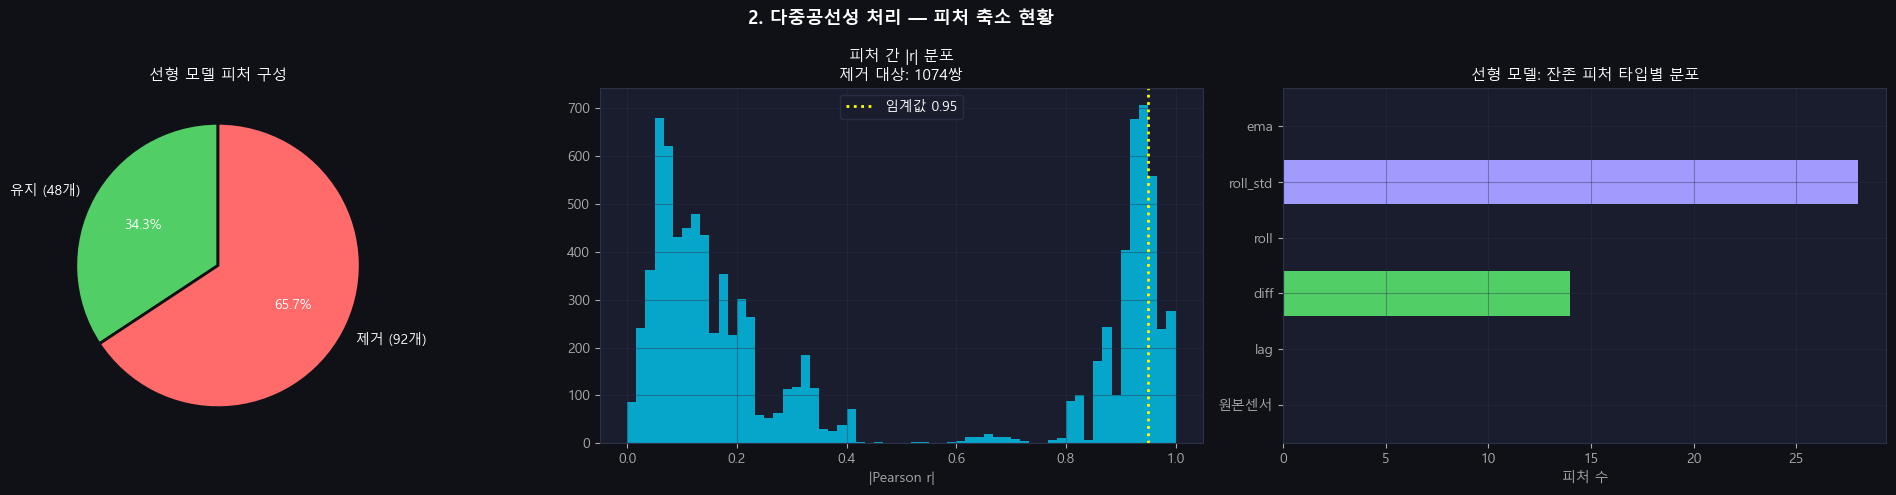


✅ 피쳐 준비 완료 (추가 스케일링 없음 — 전처리 MinMaxScaler 유지)
   선형 입력: (16561, 48) | 트리 입력: (16561, 140)
📄 고상관 피처쌍 저장: results_ml\high_corr_pairs_linear_filter.csv


In [4]:

print('=== 2. 피처 준비 — 다중공선성 처리 ===')

corr_mat = X_sub.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = {col for col in upper.columns if any(upper[col] > CORR_THR)}

FEATURES_LINEAR = [f for f in MODEL_FEATURES if f not in to_drop]
FEATURES_TREE   = MODEL_FEATURES.copy()

print(f'전체 피처         : {len(MODEL_FEATURES):3d}개')
print(f'제거 피처         : {len(to_drop):3d}개  (|r|>{CORR_THR})')
print(f'선형 모델용 피처  : {len(FEATURES_LINEAR):3d}개')
print(f'트리 모델용 피처  : {len(FEATURES_TREE):3d}개')

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('2. 다중공선성 처리 — 피처 축소 현황', fontsize=13, fontweight='bold')

wedges, _, auts = axes[0].pie(
    [len(FEATURES_LINEAR), len(to_drop)],
    labels=[f'유지 ({len(FEATURES_LINEAR)}개)', f'제거 ({len(to_drop)}개)'],
    colors=[C[2], C[1]], autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': BG}
)
for a in auts:
    a.set_color(WHITE)
axes[0].set_title('선형 모델 피처 구성')
axes[0].set_facecolor(BG2)

corr_vals = upper.stack().values
axes[1].hist(corr_vals[corr_vals > 0], bins=60, color=C[0], alpha=0.75)
axes[1].axvline(CORR_THR, color='yellow', lw=2, ls=':', label=f'임계값 {CORR_THR}')
axes[1].set_title(f'피처 간 |r| 분포\n제거 대상: {(corr_vals > CORR_THR).sum()}쌍')
axes[1].set_xlabel('|Pearson r|')
axes[1].legend()

kept = pd.Series(FEATURES_LINEAR)
types = {
    '원본센서': kept[~kept.str.contains('_')].count(),
    'lag': kept[kept.str.contains('lag')].count(),
    'diff': kept[kept.str.contains('diff')].count(),
    'roll': kept[kept.str.contains('roll') & ~kept.str.contains('std')].count(),
    'roll_std': kept[kept.str.contains('roll_std')].count(),
    'ema': kept[kept.str.contains('ema')].count(),
}
axes[2].barh(list(types.keys()), list(types.values()),
             color=[C[i % len(C)] for i in range(len(types))])
axes[2].set_title('선형 모델: 잔존 피처 타입별 분포')
axes[2].set_xlabel('피처 수')
plt.tight_layout()
plt.show()

# ── 선형 모델용 스케일링 ──────────────────────────────────────────────
Xls_sub  = X_sub[FEATURES_LINEAR].copy()
Xls_val  = X_val[FEATURES_LINEAR].copy()
Xls_test = X_test[FEATURES_LINEAR].copy()

print('\n✅ 피쳐 준비 완료 (추가 스케일링 없음 — 전처리 MinMaxScaler 유지)')
print(f'   선형 입력: {Xls_sub.shape} | 트리 입력: {X_sub.shape}')

corr_pairs_path = os.path.join(RESULT_DIR, 'high_corr_pairs_linear_filter.csv')
high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0':'feat_a', 'level_1':'feat_b', 0:'abs_corr'})
         .query('abs_corr > @CORR_THR')
         .sort_values('abs_corr', ascending=False)
)
high_corr_pairs.to_csv(corr_pairs_path, index=False)
print(f'📄 고상관 피처쌍 저장: {corr_pairs_path}')



## 3. 실험 설계 — CV 전략, 평가 지표, 일관된 clipping

이번 버전은 **모든 단계에서 음수 예측을 0으로 clipping**하여 평가를 일관화합니다.  
또한 모델 선택은 **Validation/CV 중심**, Test는 최종 확인용으로만 사용합니다.


In [5]:

print('=== 3. 실험 설계 ===')

gkf = GroupKFold(n_splits=N_SPLITS_CV)

fold_rows = []
for fold, (ti, vi) in enumerate(gkf.split(X_sub, y_sub, groups), 1):
    fold_rows.append({
        'Fold': fold,
        'Train엔진': len(set(groups[ti])),
        'Valid엔진': len(set(groups[vi])),
        'Train행수': len(ti),
        'Valid행수': len(vi)
    })
print('GroupKFold CV 분포:')
display(pd.DataFrame(fold_rows).set_index('Fold'))

# ── Validation 평가용 마지막 사이클 추출 ────────────────────────────────────────────────
# NASA Score는 엔진당 1개 예측값 기준으로 계산해야 Test와 비교 가능
# (전체 사이클 합산 시 행 수 비례로 스케일이 달라져 Test와 비교 불가)
val_eval = (valid.sort_values(['unit_nr', 'time_cycles'])
                 .groupby('unit_nr', as_index=False)
                 .last()
                 .reset_index(drop=True))
X_val_eval = val_eval[MODEL_FEATURES].copy()
y_val_eval = val_eval['RUL'].copy()

print(f'val_eval (마지막 사이클) : {val_eval.shape}  | 엔진 {val_eval["unit_nr"].nunique()}대')

def clip_rul(pred):
    pred = np.asarray(pred, dtype=float)
    return np.clip(pred, CLIP_LOWER, None)

def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def get_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'NASA_Score': float(nasa_score(y_true, y_pred)),
    }

def get_eval_nasa(model, X_eval, y_eval):
    """NASA Score - 엔진별 마지막 사이클 기준 (Test와 동일한 방식)"""
    pred = clip_rul(model.predict(X_eval))
    return float(nasa_score(y_eval, pred))

def cv_score(model_builder, X, y, grp):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr, Xva = X.iloc[ti].copy(), X.iloc[vi].copy()
        ytr, yva = y.iloc[ti], y.iloc[vi]
        model = model_builder()
        model.fit(Xtr, ytr)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(np.sqrt(mean_squared_error(yva, pred)))
        nasa_list.append(nasa_score(yva, pred))
    return {
        'cv_rmse_mean': float(np.mean(rmse_list)),
        'cv_rmse_std': float(np.std(rmse_list)),
        'cv_nasa_mean': float(np.mean(nasa_list)),
    }

def rank_tuple(res):
    """Val NASA(eval) 1순위 -> Val RMSE 2순위"""
    return (
        res['val_eval_nasa'],
        res['val_metrics']['RMSE'],
    )

print('\n✅ 평가 함수 준비 완료')
print('   - clipping: 모든 평가 단계에 동일 적용')
print('   - NASA Score: 엔진별 마지막 사이클 기준 (Test와 동일한 방식)')
print('   - 모델 선택: Val NASA(eval) → Val RMSE 순')


=== 3. 실험 설계 ===
GroupKFold CV 분포:


,Train엔진,Valid엔진,Train행수,Valid행수
Fold,,,,
1,64,16,13250,3311
2,64,16,13258,3303
3,64,16,13251,3310
4,64,16,13242,3319
5,64,16,13243,3318


val_eval (마지막 사이클) : (20, 147)  | 엔진 20대

✅ 평가 함수 준비 완료
   - clipping: 모든 평가 단계에 동일 적용
   - NASA Score: 엔진별 마지막 사이클 기준 (Test와 동일한 방식)
   - 모델 선택: Val NASA(eval) → Val RMSE 순



## 4. MLflow 설정

- Tracking URI: 로컬 `mlruns/`
- Experiment: `CMAPSS_FD001_ML_`
- 각 모델은 **nested run**으로 기록
- 기록 항목:
  - 하이퍼파라미터
  - CV / Validation / Test 메트릭
  - 모델 파일
  - 성능표 / 중요도표 / 요약 CSV


In [6]:
from pathlib import Path
import os
import mlflow

print('=== 4. MLflow 설정 ===')

os.makedirs(MLFLOW_DIR, exist_ok=True)

tracking_uri = Path(MLFLOW_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

PARENT_RUN = mlflow.start_run(run_name='FD001_ML_parent')
mlflow.log_params({
    'dataset': 'FD001',
    'split_strategy': 'GroupShuffleSplit random_state=42 from preprocessing',
    'cv_strategy': f'GroupKFold({N_SPLITS_CV})',
    'corr_threshold': CORR_THR,
    'n_trials_linear': N_TRIALS_LIN,
    'n_trials_tree': N_TRIALS_TRE,
    'clip_lower': CLIP_LOWER,
})

print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {EXPERIMENT_NAME}')
print(f'Parent Run ID: {PARENT_RUN.info.run_id}')
print('✅ MLflow 준비 완료')


=== 4. MLflow 설정 ===
Tracking URI : file:///C:/Users/matth/OneDrive/%EB%B0%94%ED%83%95%20%ED%99%94%EB%A9%B4/%EB%B6%80%EC%BA%A0/%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8/%EC%B5%9C%EC%A2%85%20%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8/cmapss/mlruns
Experiment   : CMAPSS_FD001_ML
Parent Run ID: 0f27f64ed8f144e5bce9628b6dbd3ece
✅ MLflow 준비 완료


## 5. 선형 모델 학습 — Ridge / Lasso / ElasticNet (Optuna + MLflow)

In [7]:

print('=== 5. 선형 모델 학습 ===')
print(f'피처 수: {len(FEATURES_LINEAR)}개 | Trials: {N_TRIALS_LIN}')
print()

ALL_RESULTS = {}
BEST_MODELS = {}

def build_linear_model_from_trial(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True))
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), max_iter=10000)
    elif name == 'ElasticNet':
        return ElasticNet(
            alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
            l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
            max_iter=10000
        )
    raise ValueError(name)

linear_models = ['Ridge', 'Lasso', 'ElasticNet']

mlflow.log_params({
    'feature_count_tree': len(FEATURES_TREE),
    'feature_count_linear': len(FEATURES_LINEAR),
})

for mname in linear_models:
    t0 = time.time()
    print(f'[{mname}] Optuna 최적화 중...')

    def objective(trial):
        def builder():
            return build_linear_model_from_trial(trial, mname)
        cv_res = cv_score(builder, Xls_sub, y_sub, groups)
        return cv_res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_params = study.best_params

    if mname == 'Ridge':
        best_model = Ridge(**best_params)
    elif mname == 'Lasso':
        best_model = Lasso(**best_params, max_iter=10000)
    else:
        best_model = ElasticNet(**best_params, max_iter=10000)

    best_model.fit(Xls_sub, y_sub)

    cv_res = cv_score(lambda: best_model.__class__(**best_model.get_params()), Xls_sub, y_sub, groups)
    val_metrics   = get_metrics(y_val, best_model.predict(Xls_val))
    val_eval_nasa = get_eval_nasa(best_model, val_eval[FEATURES_LINEAR], y_val_eval)
    test_metrics  = get_metrics(y_test, best_model.predict(Xls_test))

    ALL_RESULTS[mname] = {
        'type': 'linear',
        'model': best_model,
        'params': best_params,
        'cv_rmse': cv_res['cv_rmse_mean'],
        'cv_rmse_std': cv_res['cv_rmse_std'],
        'cv_nasa': cv_res['cv_nasa_mean'],
        'val_metrics': val_metrics,
        'val_eval_nasa': val_eval_nasa,
        'test_metrics': test_metrics,
        'fit_seconds': time.time() - t0,
        'feature_count': len(FEATURES_LINEAR),
        'features_used': FEATURES_LINEAR,
    }
    BEST_MODELS[mname] = best_model

    with mlflow.start_run(run_name=mname, nested=True):
        mlflow.set_tags({'model_family': 'linear', 'model_name': mname})
        mlflow.log_params(best_params)
        mlflow.log_params({
            'feature_count': len(FEATURES_LINEAR),
            'uses_scaler': False,
        })
        mlflow.log_metrics({
            'cv_rmse': cv_res['cv_rmse_mean'],
            'cv_rmse_std': cv_res['cv_rmse_std'],
            'cv_nasa': cv_res['cv_nasa_mean'],
            'val_rmse': val_metrics['RMSE'],
            'val_mae': val_metrics['MAE'],
            'val_r2': val_metrics['R2'],
            'val_eval_nasa': val_eval_nasa,
            'test_rmse': test_metrics['RMSE'],
            'test_mae': test_metrics['MAE'],
            'test_r2': test_metrics['R2'],
            'test_nasa': test_metrics['NASA_Score'],
            'fit_seconds': ALL_RESULTS[mname]['fit_seconds'],
        })
        mlflow.sklearn.log_model(best_model, artifact_path=f'model_{mname}')

    print(f'  완료 | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_metrics["RMSE"]:.3f} | Val NASA(eval)={val_eval_nasa:.1f} | Test NASA={test_metrics["NASA_Score"]:.1f}')


=== 5. 선형 모델 학습 ===
피처 수: 48개 | Trials: 5

[Ridge] Optuna 최적화 중...


2026/04/21 22:08:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:08:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=20.408 | Val RMSE=18.929 | Val NASA(eval)=31.2 | Test NASA=1718.6
[Lasso] Optuna 최적화 중...


2026/04/21 22:10:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:10:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=20.416 | Val RMSE=18.925 | Val NASA(eval)=28.0 | Test NASA=1665.9
[ElasticNet] Optuna 최적화 중...


2026/04/21 22:13:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:13:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=20.473 | Val RMSE=19.050 | Val NASA(eval)=31.9 | Test NASA=1512.6


## 6. 트리 모델 학습 — RandomForest / XGBoost / LightGBM (Optuna + MLflow)

In [8]:

print('=== 6. 트리 모델 학습 ===')
print(f'피처 수: {len(FEATURES_TREE)}개 | Trials: {N_TRIALS_TRE}')
print()

def build_tree_model_from_trial(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 5, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            max_features=trial.suggest_float('max_features', 0.2, 1.0),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 15, 255),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    raise ValueError(name)

tree_models = ['RandomForest', 'XGBoost', 'LightGBM']

for mname in tree_models:
    t0 = time.time()
    print(f'[{mname}] Optuna 최적화 중...')

    def objective(trial):
        def builder():
            return build_tree_model_from_trial(trial, mname)
        cv_res = cv_score(builder, X_sub, y_sub, groups)
        return cv_res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_TRE, show_progress_bar=False)

    best_params = study.best_params
    best_model = build_tree_model_from_trial(optuna.trial.FixedTrial(best_params), mname)
    best_model.fit(X_sub, y_sub)

    cv_res = cv_score(lambda: best_model.__class__(**best_model.get_params()), X_sub, y_sub, groups)
    val_metrics   = get_metrics(y_val,  best_model.predict(X_val))
    val_eval_nasa = get_eval_nasa(best_model, X_val_eval, y_val_eval)
    test_metrics  = get_metrics(y_test, best_model.predict(X_test))

    ALL_RESULTS[mname] = {
        'type': 'tree',
        'model': best_model,
        'params': best_params,
        'cv_rmse': cv_res['cv_rmse_mean'],
        'cv_rmse_std': cv_res['cv_rmse_std'],
        'cv_nasa': cv_res['cv_nasa_mean'],
        'val_metrics': val_metrics,
        'val_eval_nasa': val_eval_nasa,
        'test_metrics': test_metrics,
        'fit_seconds': time.time() - t0,
        'feature_count': len(FEATURES_TREE),
        'features_used': FEATURES_TREE,
    }
    BEST_MODELS[mname] = best_model

    with mlflow.start_run(run_name=mname, nested=True):
        mlflow.set_tags({'model_family': 'tree', 'model_name': mname})
        mlflow.log_params(best_params)
        mlflow.log_params({
            'feature_count': len(FEATURES_TREE),
            'uses_scaler': False,
        })
        mlflow.log_metrics({
            'cv_rmse': cv_res['cv_rmse_mean'],
            'cv_rmse_std': cv_res['cv_rmse_std'],
            'cv_nasa': cv_res['cv_nasa_mean'],
            'val_rmse': val_metrics['RMSE'],
            'val_mae': val_metrics['MAE'],
            'val_r2': val_metrics['R2'],
            'val_eval_nasa': val_eval_nasa,
            'test_rmse': test_metrics['RMSE'],
            'test_mae': test_metrics['MAE'],
            'test_r2': test_metrics['R2'],
            'test_nasa': test_metrics['NASA_Score'],
            'fit_seconds': ALL_RESULTS[mname]['fit_seconds'],
        })
        mlflow.sklearn.log_model(best_model, artifact_path=f'model_{mname}')

    print(f'  완료 | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_metrics["RMSE"]:.3f} | Val NASA(eval)={val_eval_nasa:.1f} | Test NASA={test_metrics["NASA_Score"]:.1f}')


=== 6. 트리 모델 학습 ===
피처 수: 140개 | Trials: 5

[RandomForest] Optuna 최적화 중...


2026/04/21 22:30:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:30:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=18.506 | Val RMSE=15.687 | Val NASA(eval)=4.1 | Test NASA=804.3
[XGBoost] Optuna 최적화 중...


2026/04/21 22:36:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:36:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=17.686 | Val RMSE=15.154 | Val NASA(eval)=9.5 | Test NASA=636.9
[LightGBM] Optuna 최적화 중...


2026/04/21 22:41:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 22:41:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=18.259 | Val RMSE=15.767 | Val NASA(eval)=6.5 | Test NASA=661.0



## 7. 모델 성능 비교

주의:  
- **모델 선택 기준은 Test가 아님**
- 순위표는 Validation/CV 중심으로 정렬
- Test는 최종 일반화 성능 확인용


In [9]:

print('=== 7. 모델 성능 비교 ===')

rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        '모델': mname,
        '구분': '선형' if res['type'] == 'linear' else '트리',
        'Feature Count': res['feature_count'],
        'CV RMSE': round(res['cv_rmse'], 3),
        'CV RMSE Std': round(res['cv_rmse_std'], 3),
        'CV NASA': round(res['cv_nasa'], 1),
        'Val RMSE': round(res['val_metrics']['RMSE'], 3),
        'Val MAE': round(res['val_metrics']['MAE'], 3),
        'Val R²': round(res['val_metrics']['R2'], 4),
        'Val NASA(eval)': round(res['val_eval_nasa'], 1),
        'Test RMSE': round(res['test_metrics']['RMSE'], 3),
        'Test MAE': round(res['test_metrics']['MAE'], 3),
        'Test R²': round(res['test_metrics']['R2'], 4),
        'Test NASA': round(res['test_metrics']['NASA_Score'], 1),
        '학습시간(초)': round(res['fit_seconds'], 1),
    })

result_df = pd.DataFrame(rows)
result_df['rank_key_1'] = result_df['Val NASA(eval)']
result_df['rank_key_2'] = result_df['Val RMSE']
result_df = result_df.sort_values(['rank_key_1', 'rank_key_2']).reset_index(drop=True)
result_df['선정순위'] = np.arange(1, len(result_df)+1)
display_cols = ['선정순위','모델','구분','Feature Count','CV RMSE','CV RMSE Std','CV NASA',
                'Val RMSE','Val MAE','Val R²','Val NASA(eval)',
                'Test RMSE','Test MAE','Test R²','Test NASA','학습시간(초)']
display(result_df[display_cols]
        .style.background_gradient(subset=['Val NASA(eval)','Val RMSE','CV RMSE','Test NASA','Test RMSE'], cmap='RdYlGn_r')
              .background_gradient(subset=['Val R²','Test R²'], cmap='RdYlGn'))

best_model_name = result_df.iloc[0]['모델']
best_res = ALL_RESULTS[best_model_name]

best_tree_name = min(tree_models, key=lambda n: rank_tuple(ALL_RESULTS[n]))
best_lin_name = min(linear_models, key=lambda n: rank_tuple(ALL_RESULTS[n]))

print(f'\n🏆 전체 최고 모델(Validation/CV 기준): {best_model_name}')
print(f'   Val RMSE={best_res["val_metrics"]["RMSE"]:.3f} | CV RMSE={best_res["cv_rmse"]:.3f} | Test RMSE={best_res["test_metrics"]["RMSE"]:.3f}')
print(f'🌲 최고 트리 모델: {best_tree_name}')
print(f'📏 최고 선형 모델: {best_lin_name}')

result_csv_path = os.path.join(RESULT_DIR, 'model_comparison.csv')
result_df[display_cols].to_csv(result_csv_path, index=False, encoding='utf-8-sig')
print(f'📄 성능표 저장: {result_csv_path}')


=== 7. 모델 성능 비교 ===


,선정순위,모델,구분,Feature Count,CV RMSE,CV RMSE Std,CV NASA,Val RMSE,Val MAE,Val R²,Val NASA(eval),Test RMSE,Test MAE,Test R²,Test NASA,학습시간(초)
0,1,RandomForest,트리,140,18.506000,1.761000,49505.000000,15.687000,10.926000,0.858600,4.100000,18.662000,13.892000,0.798300,804.300000,1047.300000
1,2,LightGBM,트리,140,18.259000,1.592000,43312.900000,15.767000,10.859000,0.857100,6.500000,19.532000,14.939000,0.779100,661.000000,280.000000
2,3,XGBoost,트리,140,17.686000,1.385000,37863.200000,15.154000,10.805000,0.868000,9.500000,18.188000,14.002000,0.808400,636.900000,342.100000
3,4,Lasso,선형,48,20.416000,0.492000,27170.800000,18.925000,15.083000,0.794200,28.000000,22.663000,17.995000,0.702600,1665.900000,90.300000
4,5,Ridge,선형,48,20.408000,0.491000,27137.300000,18.929000,15.080000,0.794100,31.200000,22.810000,18.143000,0.698700,1718.600000,1.300000
5,6,ElasticNet,선형,48,20.473000,0.531000,27353.800000,19.050000,15.179000,0.791500,31.900000,22.333000,17.840000,0.711200,1512.600000,121.000000



🏆 전체 최고 모델(Validation/CV 기준): RandomForest
   Val RMSE=15.687 | CV RMSE=18.506 | Test RMSE=18.662
🌲 최고 트리 모델: RandomForest
📏 최고 선형 모델: Lasso
📄 성능표 저장: results_ml\model_comparison.csv


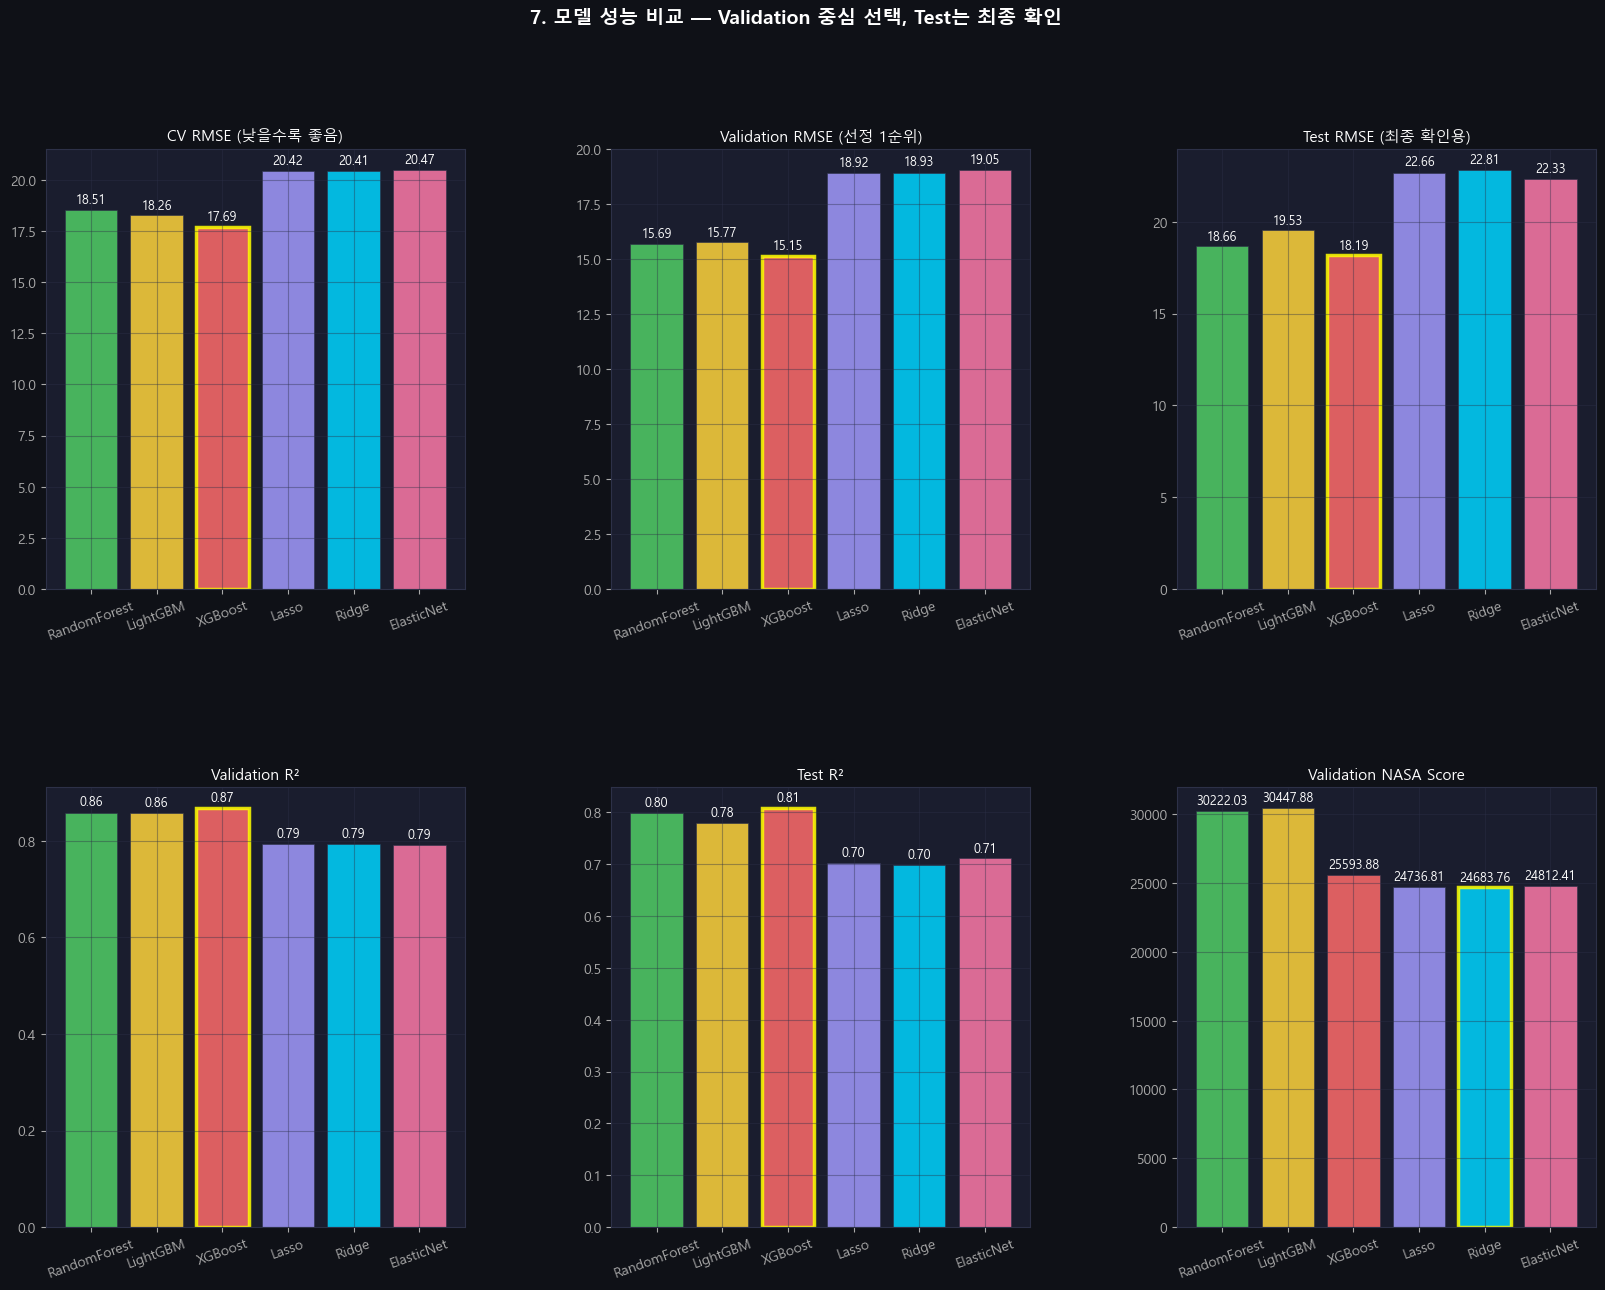

In [10]:

# 6개 모델 성능 시각화
model_names = result_df['모델'].tolist()
colors_bar = [MODEL_COLORS[m] for m in model_names]

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('7. 모델 성능 비교 — Validation 중심 선택, Test는 최종 확인', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics_cfg = [
    ('CV RMSE', 'cv_rmse', True, 'CV RMSE (낮을수록 좋음)'),
    ('Val RMSE', 'val_metrics.RMSE', True, 'Validation RMSE (선정 1순위)'),
    ('Test RMSE', 'test_metrics.RMSE', True, 'Test RMSE (최종 확인용)'),
    ('Val R²', 'val_metrics.R2', False, 'Validation R²'),
    ('Test R²', 'test_metrics.R2', False, 'Test R²'),
    ('Val NASA', 'val_metrics.NASA_Score', True, 'Validation NASA Score'),
]

def get_nested_value(res, key):
    if '.' in key:
        a, b = key.split('.')
        return res[a][b]
    return res[key]

for idx, (_, key, lower_better, title) in enumerate(metrics_cfg):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    vals = [get_nested_value(ALL_RESULTS[m], key) for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, alpha=0.85, edgecolor=GRID, linewidth=0.5)

    best_i = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_i].set_edgecolor('yellow')
    bars[best_i].set_linewidth(2.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01 if v >= 0 else v,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, color=WHITE)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


## 8. Test 세트 상세 평가 — 엔진 100대 마지막 사이클

In [11]:

print('=== 8. Test 세트 상세 평가 ===')

def predict_for_result(res, X_linear, X_tree):
    model = res['model']
    if res['type'] == 'linear':
        return clip_rul(model.predict(X_linear))
    return clip_rul(model.predict(X_tree))

test_pred_all = {}
for mname, res in ALL_RESULTS.items():
    test_pred_all[mname] = predict_for_result(res, Xls_test, X_test)

test_detail = test_eval[['unit_nr', 'time_cycles', 'RUL']].copy()
for mname, pred in test_pred_all.items():
    test_detail[f'{mname}_pred'] = np.round(pred, 1)
    test_detail[f'{mname}_err'] = np.round(pred - test_detail['RUL'].values, 1)

display(test_detail.head(15))

err_summary = []
for mname, pred in test_pred_all.items():
    errs = pred - y_test.values
    err_summary.append({
        '모델': mname,
        '평균 오차(bias)': round(errs.mean(), 2),
        '오차 표준편차': round(errs.std(), 2),
        '조기예측 비율': f'{(errs < 0).mean()*100:.1f}%',
        '늦은예측 비율': f'{(errs > 0).mean()*100:.1f}%',
        '|오차|≤10 비율': f'{(np.abs(errs) <= 10).mean()*100:.1f}%',
        '|오차|≤20 비율': f'{(np.abs(errs) <= 20).mean()*100:.1f}%',
    })
err_summary_df = pd.DataFrame(err_summary).set_index('모델')
display(err_summary_df)

test_detail_path = os.path.join(RESULT_DIR, 'test_engine_predictions.csv')
test_detail.to_csv(test_detail_path, index=False, encoding='utf-8-sig')
print(f'📄 엔진별 test 예측 저장: {test_detail_path}')


=== 8. Test 세트 상세 평가 ===


,unit_nr,time_cycles,RUL,Ridge_pred,Ridge_err,Lasso_pred,Lasso_err,ElasticNet_pred,ElasticNet_err,RandomForest_pred,RandomForest_err,XGBoost_pred,XGBoost_err,LightGBM_pred,LightGBM_err
0,1,31,112,129.2,17.2,127.6,15.6,127.6,15.6,119.1,7.1,119.0,7.0,119.2,7.2
1,2,49,98,100.5,2.5,99.7,1.7,101.1,3.1,114.9,16.9,115.7,17.7,119.5,21.5
2,3,126,69,77.5,8.5,76.8,7.8,74.3,5.3,52.0,-17.0,72.8,3.8,62.0,-7.0
3,4,106,82,78.8,-3.2,78.8,-3.2,78.3,-3.7,90.9,8.9,89.7,7.7,96.1,14.1
4,5,98,91,91.9,0.9,91.2,0.2,88.6,-2.4,91.9,0.9,106.6,15.6,100.3,9.3
5,6,105,93,120.8,27.8,120.5,27.5,113.9,20.9,115.4,22.4,121.7,28.7,119.3,26.3
6,7,160,91,90.7,-0.3,91.1,0.1,88.6,-2.4,102.0,11.0,102.4,11.4,89.2,-1.8
7,8,166,95,76.9,-18.1,76.5,-18.5,77.6,-17.4,87.1,-7.9,82.9,-12.1,80.6,-14.4
8,9,55,111,104.0,-7.0,103.7,-7.3,103.6,-7.4,107.6,-3.4,106.3,-4.7,103.4,-7.6
9,10,192,96,96.1,0.1,96.1,0.1,95.1,-0.9,96.8,0.8,96.2,0.2,94.9,-1.1


,평균 오차(bias),오차 표준편차,조기예측 비율,늦은예측 비율,|오차|≤10 비율,|오차|≤20 비율
모델,,,,,,
Ridge,7.01,21.71,32.0%,68.0%,36.0%,61.0%
Lasso,6.58,21.69,32.0%,68.0%,37.0%,62.0%
ElasticNet,5.82,21.56,39.0%,61.0%,34.0%,65.0%
RandomForest,0.32,18.66,43.0%,57.0%,52.0%,73.0%
XGBoost,0.50,18.18,44.0%,56.0%,44.0%,76.0%
LightGBM,-1.97,19.43,49.0%,51.0%,48.0%,70.0%


📄 엔진별 test 예측 저장: results_ml\test_engine_predictions.csv


## 9. 잔차 분석 — Validation 세트 구간별 오차 패턴

=== 9. 잔차 분석 ===


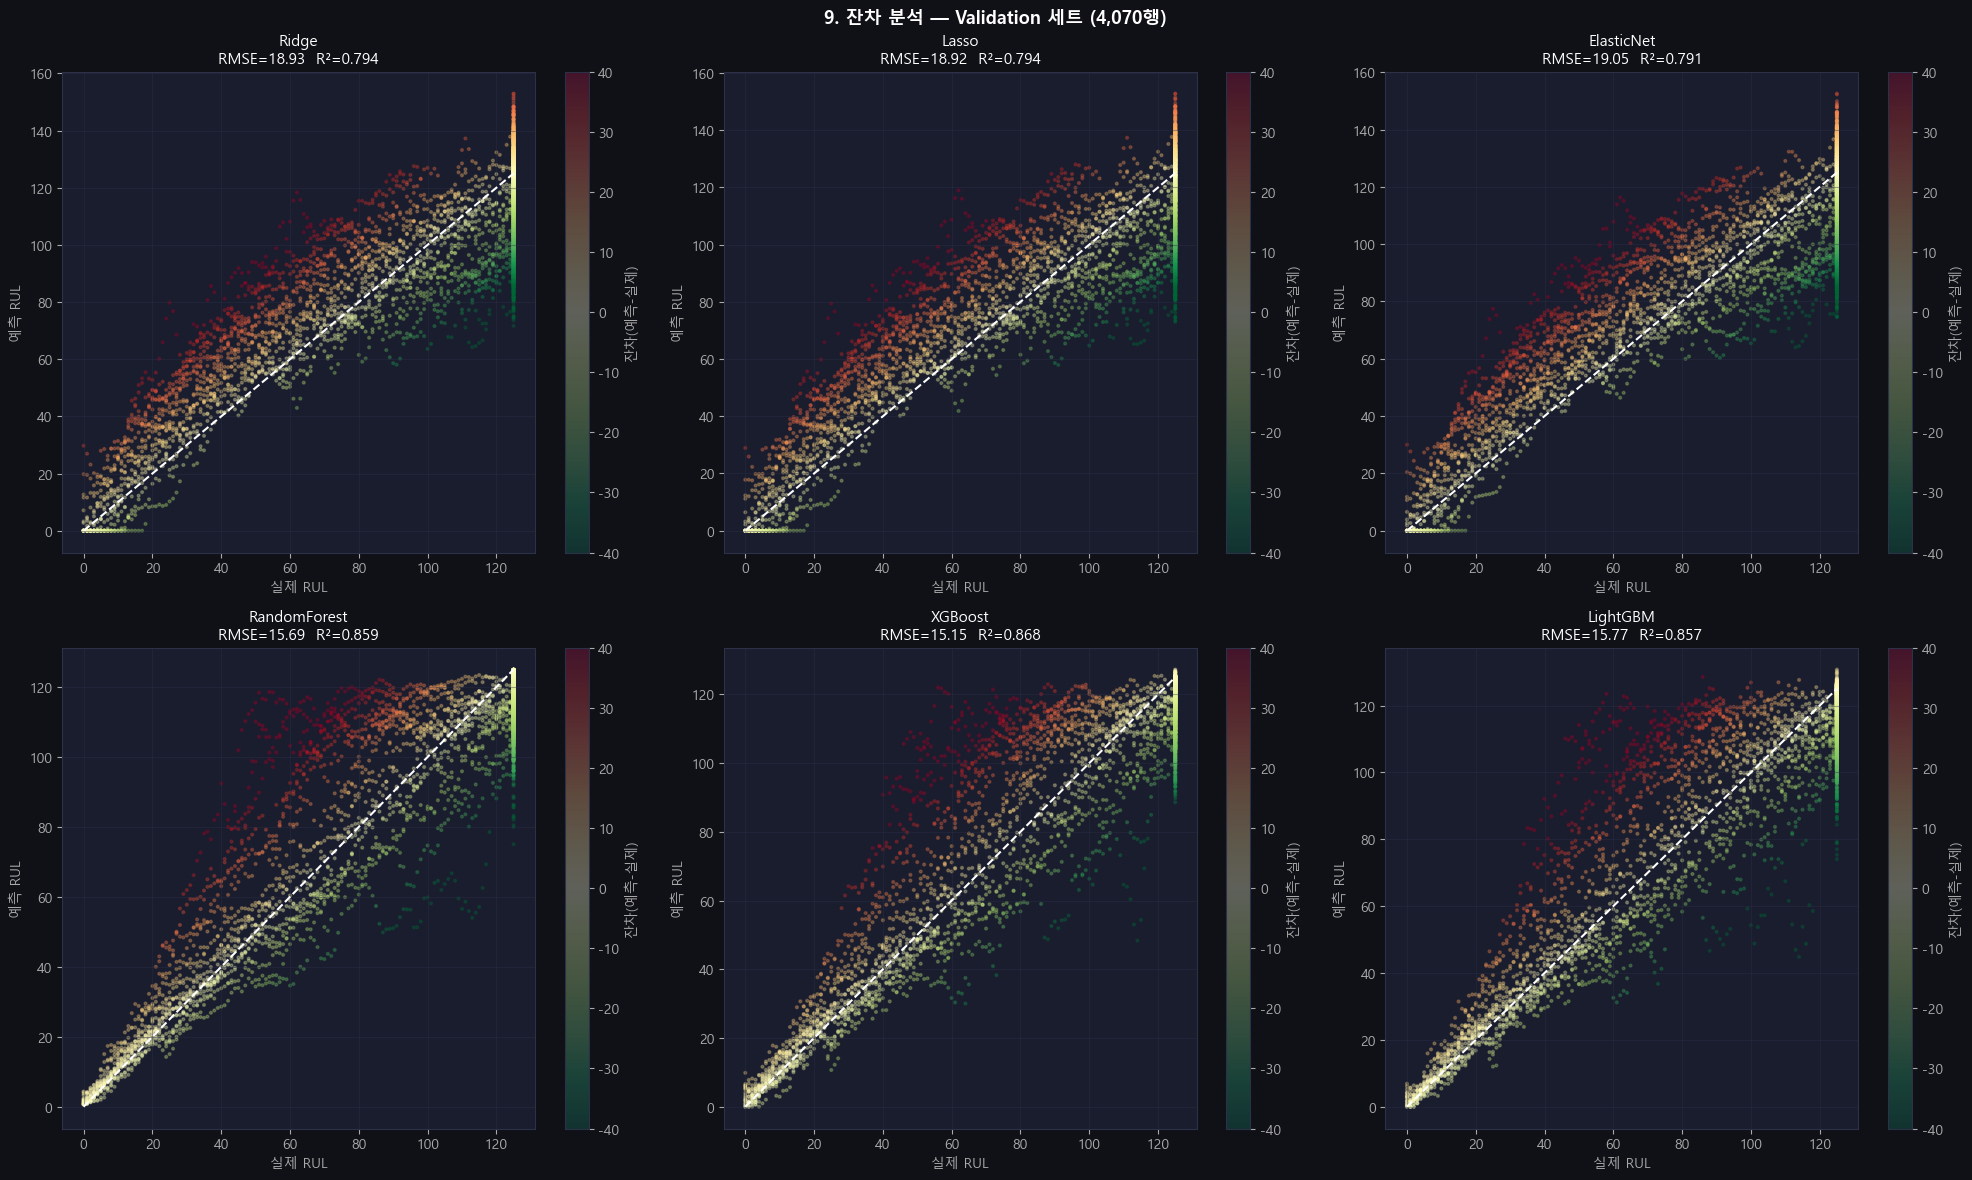

,말기(0~30),중기(31~80),초기(81~125)
모델,,,
Ridge,12.020000,16.700000,15.260000
Lasso,12.030000,16.740000,15.240000
ElasticNet,12.190000,16.860000,15.310000
RandomForest,4.320000,16.560000,10.320000
XGBoost,4.330000,16.360000,10.180000
LightGBM,4.140000,16.470000,10.280000


📄 구간별 MAE 저장: results_ml\validation_segment_mae.csv


In [12]:

print('=== 9. 잔차 분석 ===')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'9. 잔차 분석 — Validation 세트 ({len(valid):,}행)', fontsize=13, fontweight='bold')

for idx, (mname, res) in enumerate(ALL_RESULTS.items()):
    ax = axes[idx//3, idx%3]
    pred_val = predict_for_result(res, Xls_val, X_val)
    resid = pred_val - y_val.values

    sc = ax.scatter(y_val, pred_val, c=resid, cmap='RdYlGn_r',
                    alpha=0.3, s=4, vmin=-40, vmax=40)
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--', label='완벽 예측선')

    m_val = get_metrics(y_val, pred_val)
    ax.set_title(f'{mname}\nRMSE={m_val["RMSE"]:.2f}  R²={m_val["R2"]:.3f}')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차(예측-실제)')

plt.tight_layout()
plt.show()

bins = [0, 30, 80, 125]
labels = ['말기(0~30)', '중기(31~80)', '초기(81~125)']
val_rul_cat = pd.cut(y_val, bins=bins, labels=labels)

seg_rows = []
for mname, res in ALL_RESULTS.items():
    pred = predict_for_result(res, Xls_val, X_val)
    row = {'모델': mname}
    for seg in labels:
        mask = (val_rul_cat == seg)
        row[seg] = round(mean_absolute_error(y_val[mask], pred[mask]), 2) if mask.sum() > 0 else np.nan
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows).set_index('모델')
display(seg_df.style.background_gradient(cmap='RdYlGn_r'))

seg_path = os.path.join(RESULT_DIR, 'validation_segment_mae.csv')
seg_df.to_csv(seg_path, encoding='utf-8-sig')
print(f'📄 구간별 MAE 저장: {seg_path}')



## 10. 피처 중요도 분석

- 트리 모델 3개: built-in feature importance
- 전체 최고 선형 모델: 절대계수 Top-N
- 전체 최고 모델: permutation importance


=== 10. 피처 중요도 분석 ===


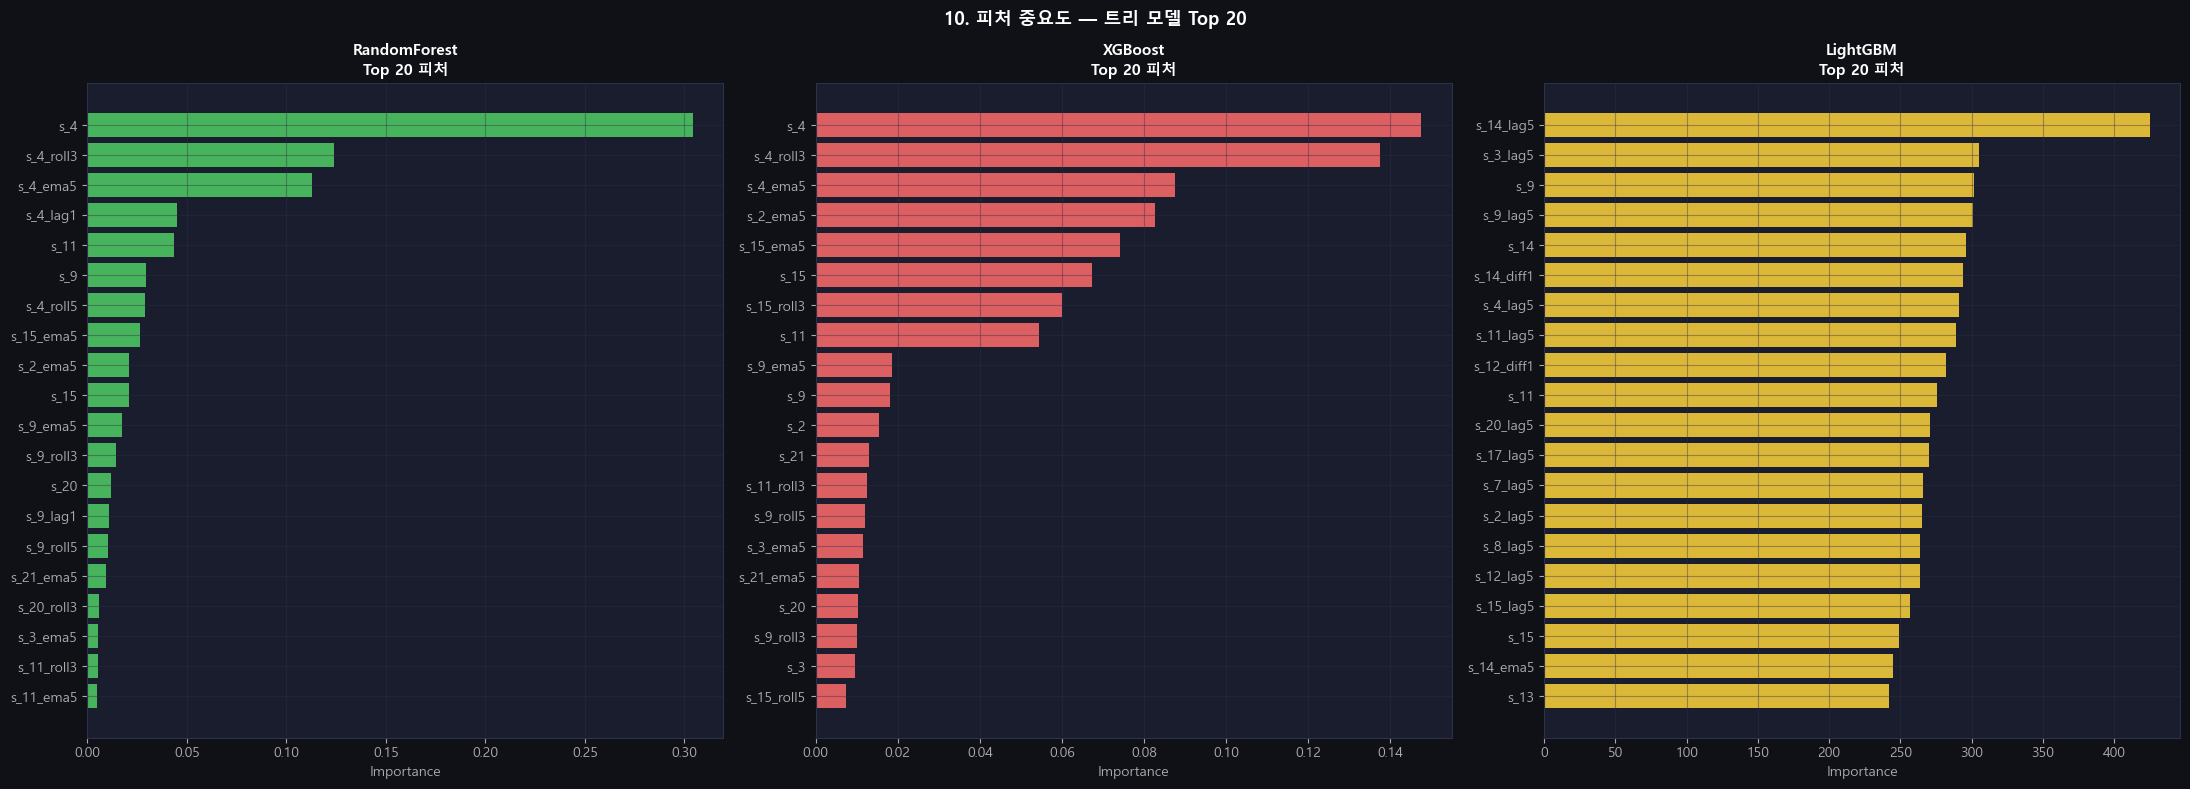


3개 트리 모델 공통 Top-10 피처 (2개):
  - s_11
  - s_9


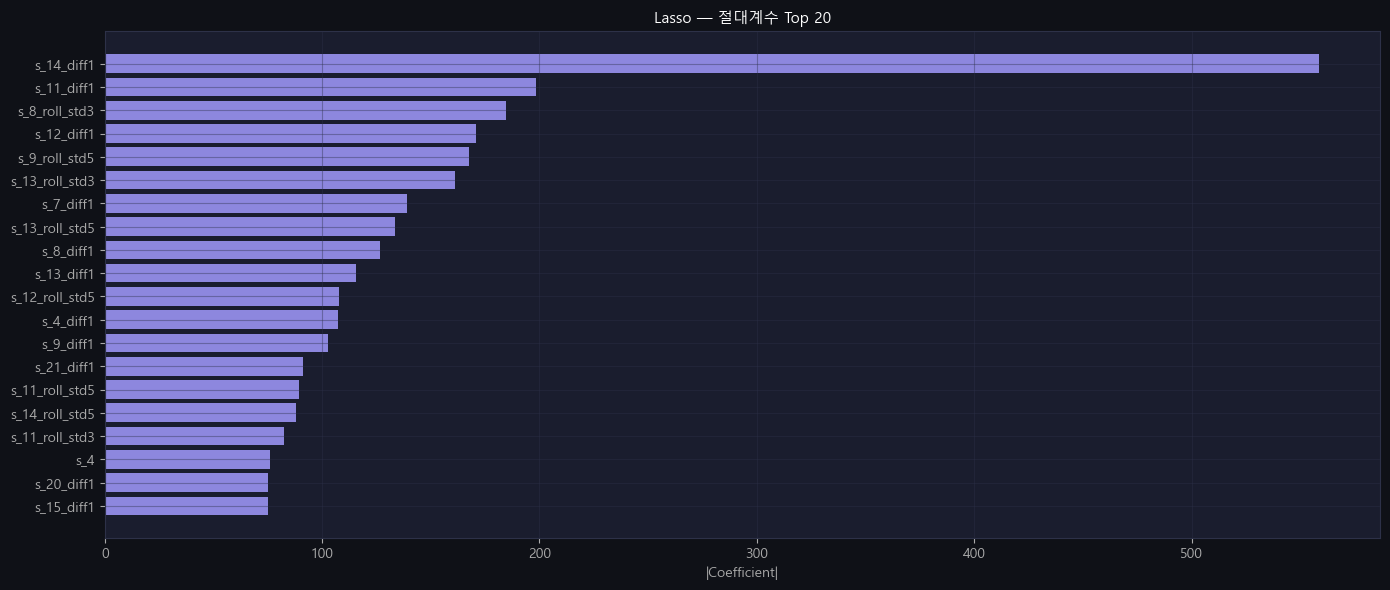

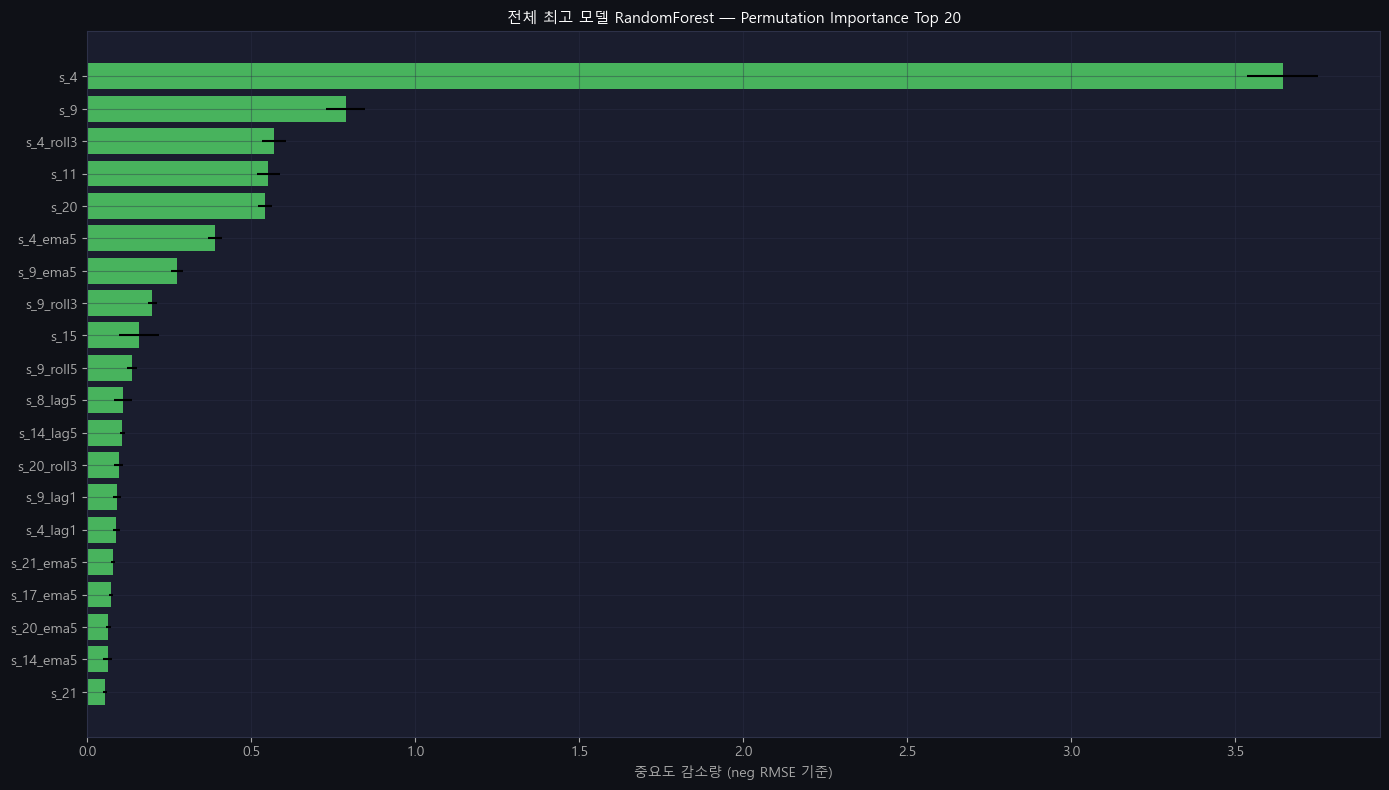

📄 permutation importance 저장: results_ml\feature_importance_RandomForest_permutation.csv


In [13]:

print('=== 10. 피처 중요도 분석 ===')

# ── 트리 모델 importance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle(f'10. 피처 중요도 — 트리 모델 Top {TOP_N_IMPORT}', fontsize=13, fontweight='bold')

fi_dfs = {}
for ax, mname in zip(axes, tree_models):
    m = BEST_MODELS[mname]
    fi = pd.Series(m.feature_importances_, index=FEATURES_TREE).nlargest(TOP_N_IMPORT)
    fi_dfs[mname] = fi
    ax.barh(fi.index[::-1], fi.values[::-1], color=MODEL_COLORS[mname], alpha=0.85)
    ax.set_title(f'{mname}\nTop {TOP_N_IMPORT} 피처', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()

# 트리 공통 상위 피처
top10_sets = {m: set(fi.nlargest(10).index) for m, fi in fi_dfs.items()}
common_top = top10_sets['RandomForest'] & top10_sets['XGBoost'] & top10_sets['LightGBM']
print(f'\n3개 트리 모델 공통 Top-10 피처 ({len(common_top)}개):')
for f in sorted(common_top):
    print('  -', f)

# ── 최고 선형 모델 절대 계수 ──────────────────────────────────────────
lin_model = BEST_MODELS[best_lin_name]
coef = pd.Series(np.abs(lin_model.coef_), index=FEATURES_LINEAR).nlargest(TOP_N_IMPORT)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(coef.index[::-1], coef.values[::-1], color=MODEL_COLORS[best_lin_name], alpha=0.85)
ax.set_title(f'{best_lin_name} — 절대계수 Top {TOP_N_IMPORT}')
ax.set_xlabel('|Coefficient|')
ax.set_facecolor(BG2)
plt.tight_layout()
plt.show()

# ── 전체 최고 모델 permutation importance ─────────────────────────────
best_model = BEST_MODELS[best_model_name]
if ALL_RESULTS[best_model_name]['type'] == 'linear':
    X_perm = Xls_val
    perm_features = FEATURES_LINEAR
else:
    X_perm = X_val
    perm_features = FEATURES_TREE

perm = permutation_importance(
    best_model, X_perm, y_val,
    n_repeats=5, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error'
)
perm_df = pd.DataFrame({
    'feature': perm_features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_perm = perm_df.head(TOP_N_IMPORT).iloc[::-1]
ax.barh(top_perm['feature'], top_perm['importance_mean'], xerr=top_perm['importance_std'],
        color=MODEL_COLORS[best_model_name], alpha=0.85)
ax.set_title(f'전체 최고 모델 {best_model_name} — Permutation Importance Top {TOP_N_IMPORT}')
ax.set_xlabel('중요도 감소량 (neg RMSE 기준)')
ax.set_facecolor(BG2)
plt.tight_layout()
plt.show()

# 저장
for mname, fi in fi_dfs.items():
    pd.DataFrame({'feature': fi.index, 'importance': fi.values}).to_csv(
        os.path.join(RESULT_DIR, f'feature_importance_{mname}.csv'),
        index=False, encoding='utf-8-sig'
    )
pd.DataFrame({'feature': coef.index, 'abs_coef': coef.values}).to_csv(
    os.path.join(RESULT_DIR, f'feature_importance_{best_lin_name}_coef.csv'),
    index=False, encoding='utf-8-sig'
)
perm_path = os.path.join(RESULT_DIR, f'feature_importance_{best_model_name}_permutation.csv')
perm_df.to_csv(perm_path, index=False, encoding='utf-8-sig')
print(f'📄 permutation importance 저장: {perm_path}')


## 10-1. SHAP 해석 — 최고 트리 모델의 영향 방향과 개별 예측 설명

=== 10-1. SHAP 해석 ===
해석 모델        : RandomForest
SHAP 대상 표본 수 : 1,000
Background 수    : 500


100%|===================| 999/1000 [06:00<00:00]        

,feature,mean_abs_shap
0,s_4,6.256575
1,s_4_roll3,2.327701
2,s_11,2.278604
3,s_4_ema5,1.950318
4,s_9,1.911353
5,s_20,1.682041
6,s_15,1.076608
7,s_9_ema5,1.073247
8,s_9_roll3,0.956225
9,s_4_lag1,0.857492


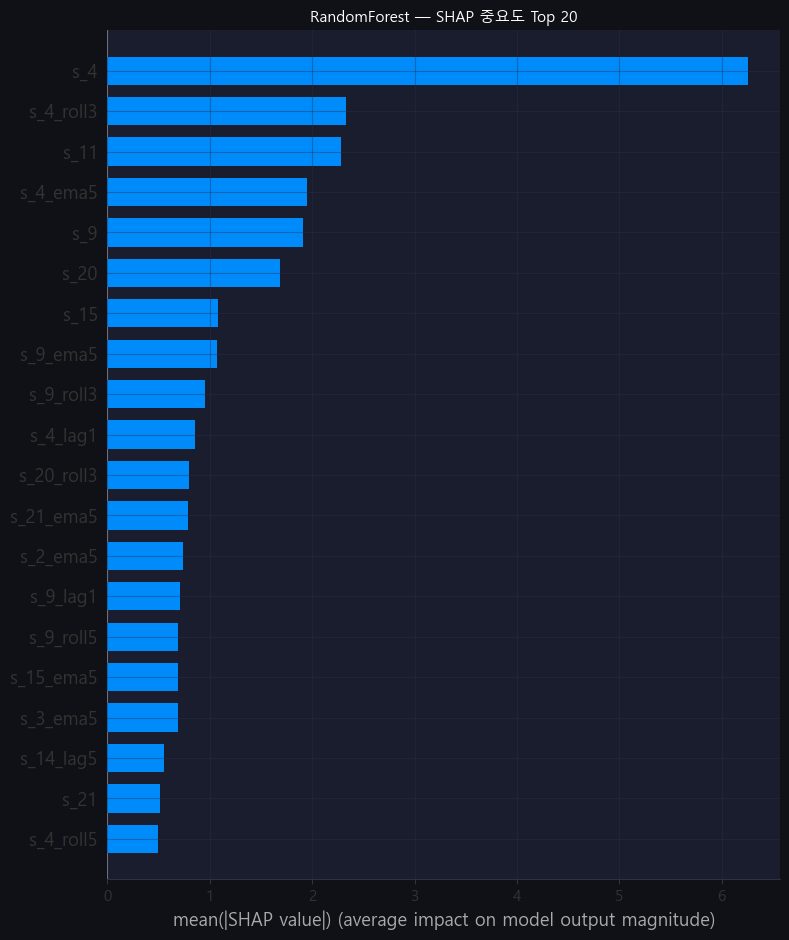

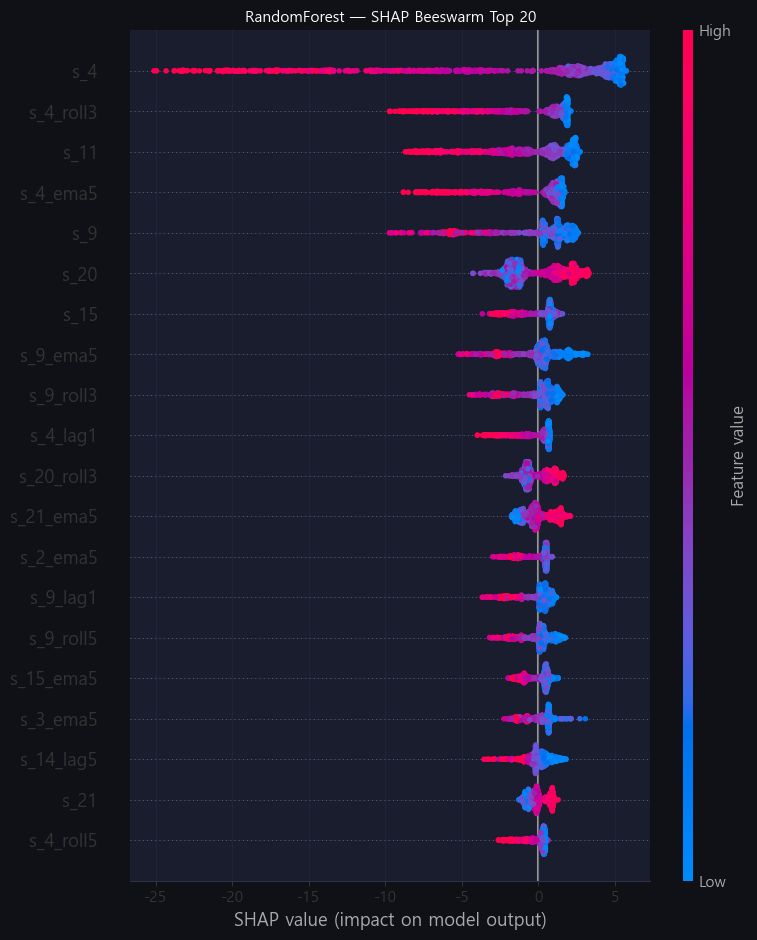

<Figure size 1000x600 with 0 Axes>

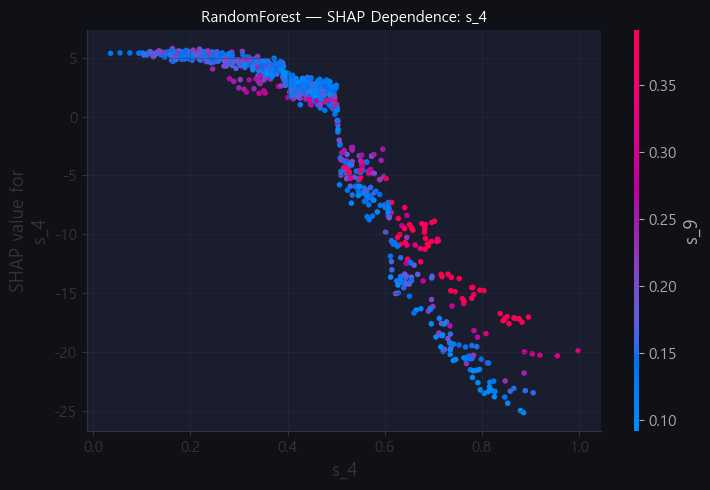

<Figure size 1000x600 with 0 Axes>

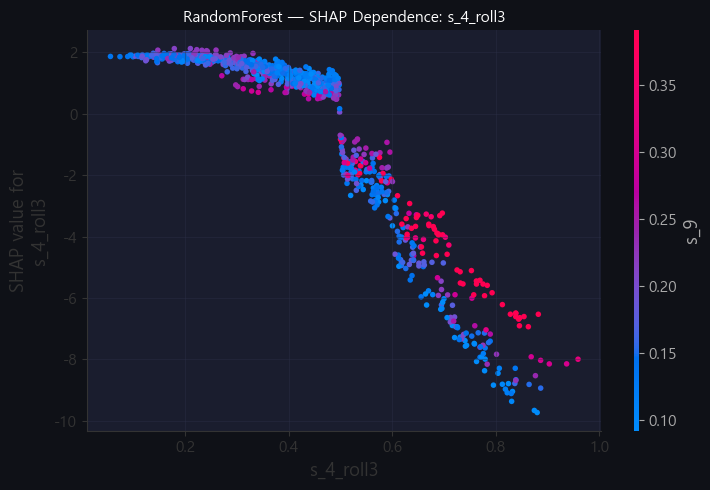

<Figure size 1000x600 with 0 Axes>

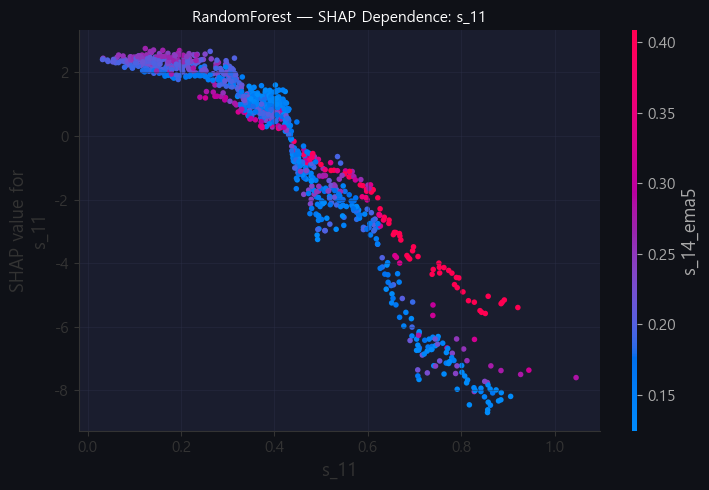

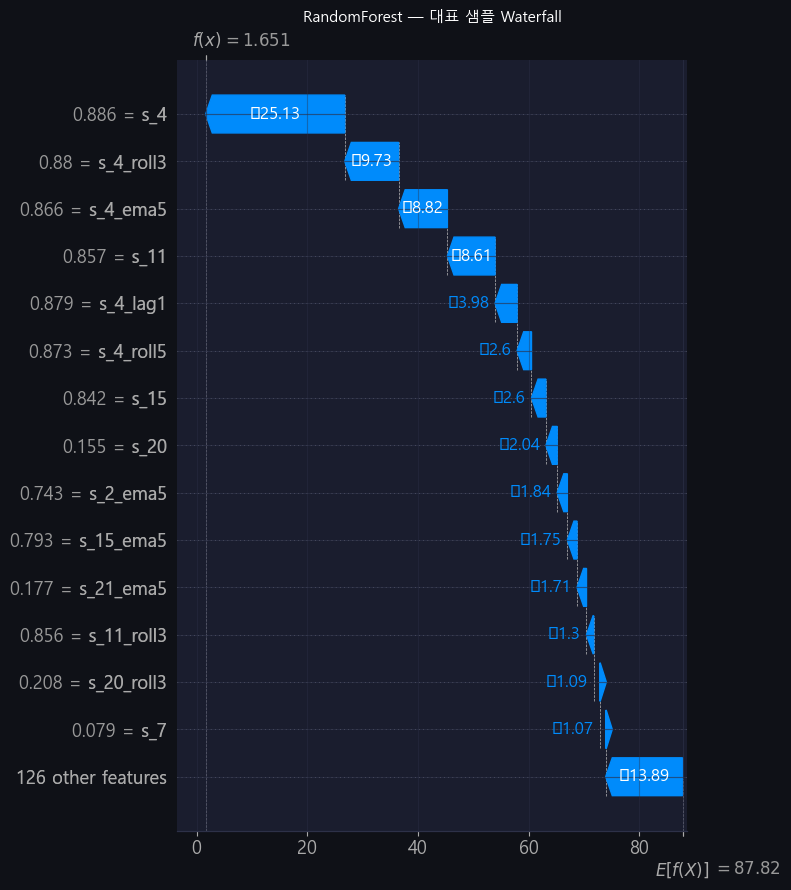

대표 샘플 index : 1018
대표 샘플 실제값 : 3.0
대표 샘플 예측값 : 1.6
📄 SHAP 중요도 저장: results_ml\shap_importance_RandomForest.csv
✅ SHAP 시각화 저장 완료


In [14]:

print('=== 10-1. SHAP 해석 ===')

# SHAP은 해석 안정성과 속도를 고려해 "최고 트리 모델" 기준으로 수행
shap_model_name = best_tree_name
shap_model = BEST_MODELS[shap_model_name]

# 표본 수 제한
X_shap_full = X_val[FEATURES_TREE].copy()
X_bg_full = X_sub[FEATURES_TREE].copy()

if len(X_shap_full) > SHAP_SAMPLE_MAX:
    X_shap = X_shap_full.sample(SHAP_SAMPLE_MAX, random_state=RANDOM_STATE)
else:
    X_shap = X_shap_full.copy()

if len(X_bg_full) > SHAP_BG_MAX:
    X_bg = X_bg_full.sample(SHAP_BG_MAX, random_state=RANDOM_STATE)
else:
    X_bg = X_bg_full.copy()

print(f'해석 모델        : {shap_model_name}')
print(f'SHAP 대상 표본 수 : {len(X_shap):,}')
print(f'Background 수    : {len(X_bg):,}')

# TreeExplainer 우선 사용
explainer = shap.TreeExplainer(shap_model, data=X_bg, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_shap)

# 모델/버전에 따라 list가 나올 수 있으므로 정리
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if hasattr(explainer, 'expected_value'):
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.array(base_value).reshape(-1)[0]
else:
    base_value = shap_model.predict(X_bg).mean()

# 절대 SHAP 평균 기준 중요도
shap_imp = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_imp.head(TOP_N_SHAP))

# 1) SHAP bar
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=TOP_N_SHAP, show=False)
plt.title(f'{shap_model_name} — SHAP 중요도 Top {TOP_N_SHAP}')
plt.tight_layout()
shap_bar_path = os.path.join(RESULT_DIR, f'shap_bar_{shap_model_name}.png')
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()

# 2) SHAP beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, max_display=TOP_N_SHAP, show=False)
plt.title(f'{shap_model_name} — SHAP Beeswarm Top {TOP_N_SHAP}')
plt.tight_layout()
shap_beeswarm_path = os.path.join(RESULT_DIR, f'shap_beeswarm_{shap_model_name}.png')
plt.savefig(shap_beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()

# 3) Dependence plot 상위 3개
top_dep_features = shap_imp.head(3)['feature'].tolist()
shap_dependence_paths = []
for feat in top_dep_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feat, shap_values, X_shap,
        interaction_index='auto',
        show=False
    )
    plt.title(f'{shap_model_name} — SHAP Dependence: {feat}')
    plt.tight_layout()
    dep_path = os.path.join(RESULT_DIR, f'shap_dependence_{shap_model_name}_{feat}.png')
    plt.savefig(dep_path, dpi=150, bbox_inches='tight')
    shap_dependence_paths.append(dep_path)
    plt.show()

# 4) Waterfall plot 대표 샘플 1개
sample_idx = int(np.argmax(np.abs(shap_values).sum(axis=1)))
sample_row = X_shap.iloc[sample_idx]
sample_pred = clip_rul(np.array([shap_model.predict(sample_row.to_frame().T)[0]]))[0]
sample_true = y_val.loc[sample_row.name] if sample_row.name in y_val.index else np.nan

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=sample_row.values,
    feature_names=X_shap.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'{shap_model_name} — 대표 샘플 Waterfall')
plt.tight_layout()
shap_waterfall_path = os.path.join(RESULT_DIR, f'shap_waterfall_{shap_model_name}.png')
plt.savefig(shap_waterfall_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'대표 샘플 index : {sample_row.name}')
print(f'대표 샘플 실제값 : {sample_true:.1f}' if pd.notna(sample_true) else '대표 샘플 실제값 : 확인 불가')
print(f'대표 샘플 예측값 : {sample_pred:.1f}')

# 저장
shap_imp_path = os.path.join(RESULT_DIR, f'shap_importance_{shap_model_name}.csv')
shap_imp.to_csv(shap_imp_path, index=False, encoding='utf-8-sig')

shap_sample_detail = pd.DataFrame({
    'sample_index': [sample_row.name],
    'true_rul': [float(sample_true) if pd.notna(sample_true) else None],
    'pred_rul': [float(sample_pred)],
    'base_value': [float(base_value)]
})
shap_sample_detail_path = os.path.join(RESULT_DIR, f'shap_sample_detail_{shap_model_name}.csv')
shap_sample_detail.to_csv(shap_sample_detail_path, index=False, encoding='utf-8-sig')

# MLflow 기록
if mlflow.active_run() is not None:
    mlflow.log_param('shap_model_name', shap_model_name)
    for artifact_path in [shap_imp_path, shap_bar_path, shap_beeswarm_path, shap_waterfall_path, shap_sample_detail_path] + shap_dependence_paths:
        if os.path.exists(artifact_path):
            mlflow.log_artifact(artifact_path)

print(f'📄 SHAP 중요도 저장: {shap_imp_path}')
print('✅ SHAP 시각화 저장 완료')


## 11. 엔진별 RUL 예측 곡선 — Validation 대표 엔진

=== 11. 엔진별 RUL 예측 곡선 ===
비교 모델: RandomForest (최고 트리) vs Lasso (최고 선형)


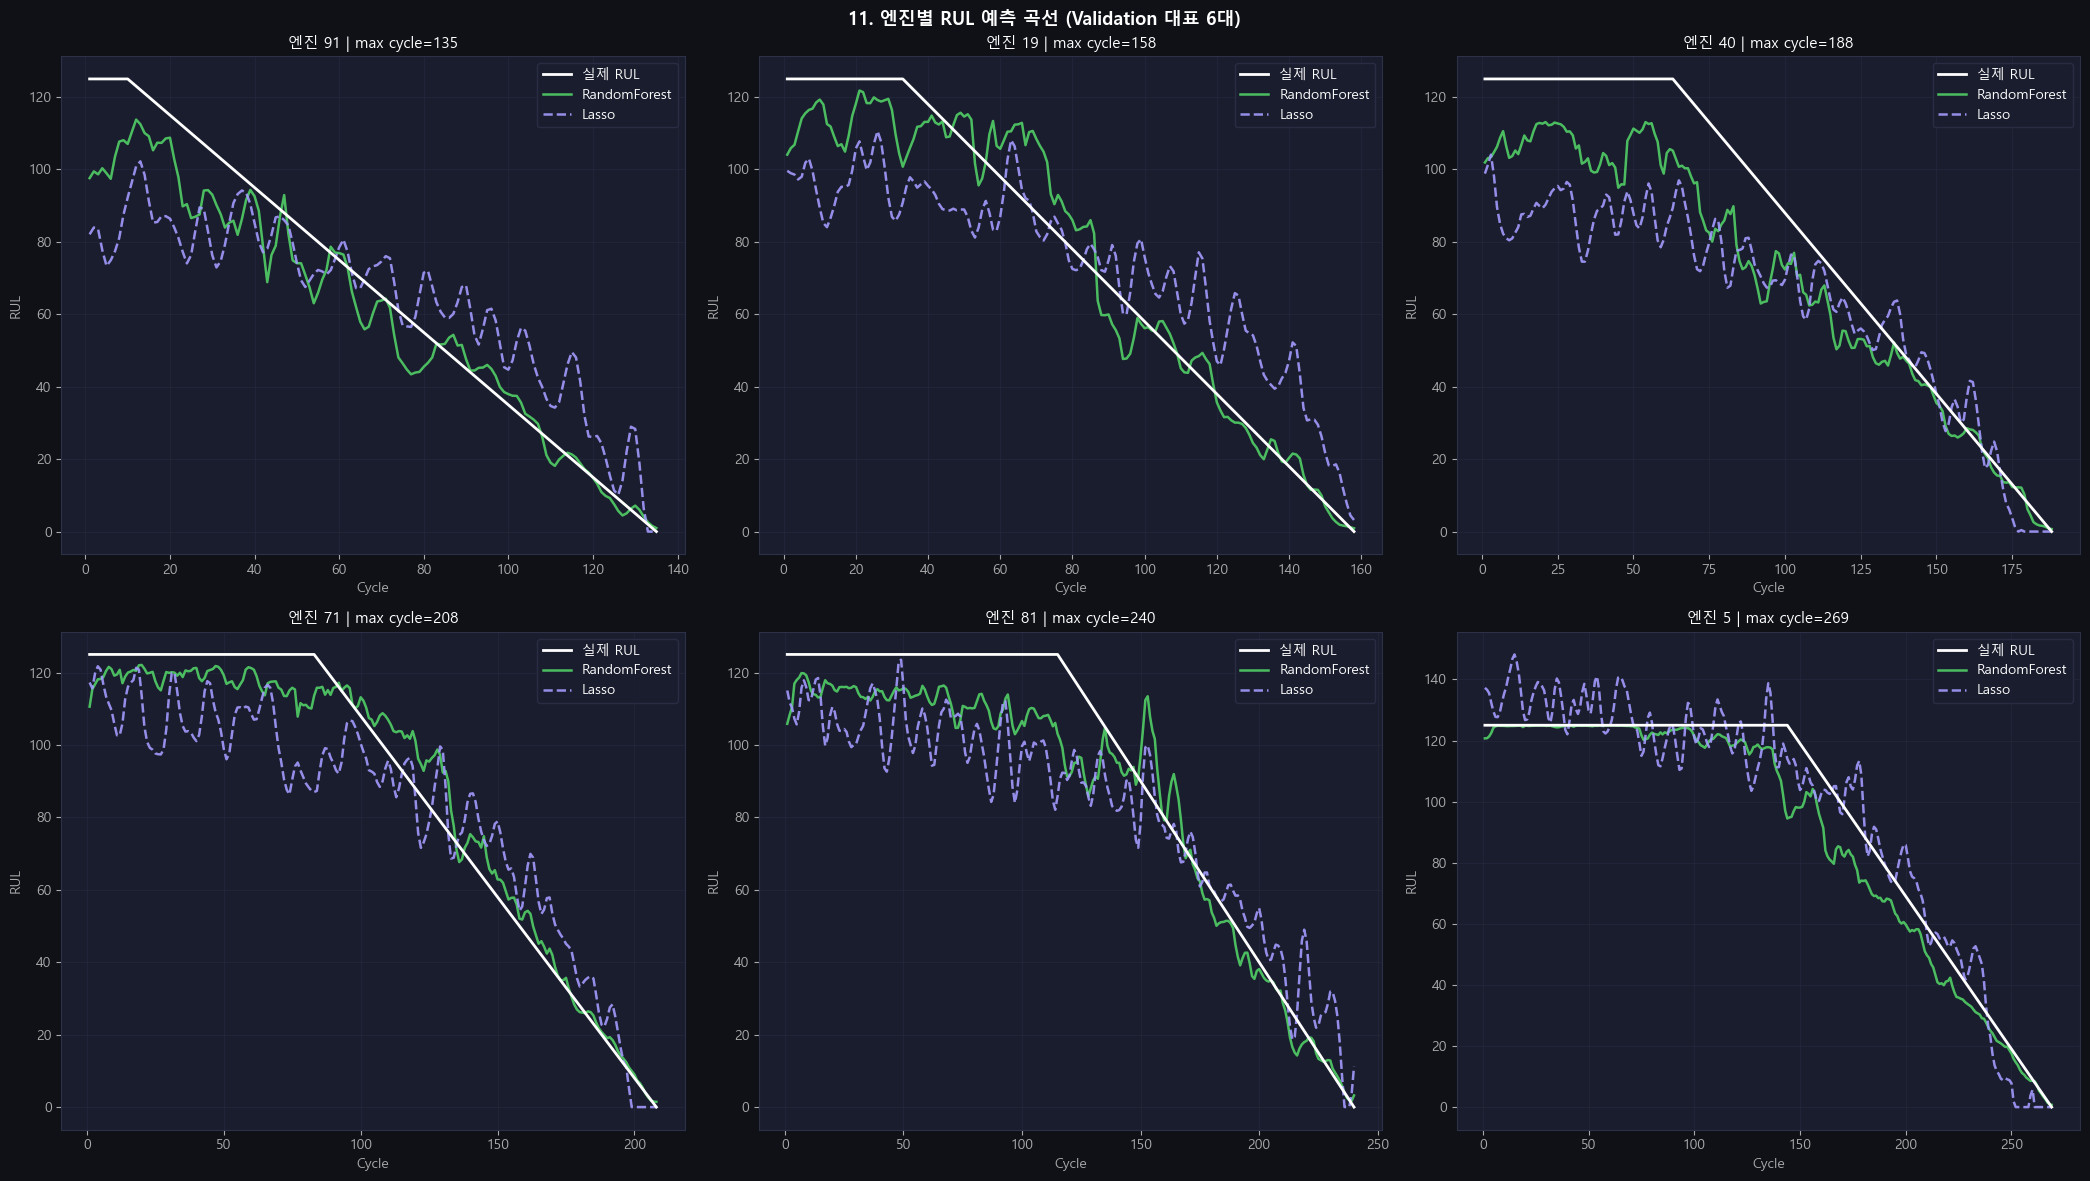

In [15]:

print('=== 11. 엔진별 RUL 예측 곡선 ===')
print(f'비교 모델: {best_tree_name} (최고 트리) vs {best_lin_name} (최고 선형)')

val_lifecycles = valid.groupby('unit_nr')['time_cycles'].max().sort_values()
n_engines = min(6, len(val_lifecycles))
idx_choices = np.linspace(0, len(val_lifecycles)-1, n_engines, dtype=int)
sel_units = val_lifecycles.iloc[idx_choices].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('11. 엔진별 RUL 예측 곡선 (Validation 대표 6대)', fontsize=13, fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf = valid[valid['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    Xin_tree = udf[FEATURES_TREE]
    Xin_lin = udf[FEATURES_LINEAR]  # MinMaxScaler 이미 적용 완료

    pred_tree = clip_rul(BEST_MODELS[best_tree_name].predict(Xin_tree))
    pred_lin = clip_rul(BEST_MODELS[best_lin_name].predict(Xin_lin))

    ax.plot(udf['time_cycles'], udf['RUL'], color='white', lw=2, label='실제 RUL', zorder=3)
    ax.plot(udf['time_cycles'], pred_tree, color=MODEL_COLORS[best_tree_name], lw=1.8, label=best_tree_name, alpha=0.9)
    ax.plot(udf['time_cycles'], pred_lin, color=MODEL_COLORS[best_lin_name], lw=1.8, ls='--', label=best_lin_name, alpha=0.9)

    ax.set_title(f'엔진 {uid} | max cycle={udf["time_cycles"].max()}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend(loc='upper right')
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


## 12. NASA Score 상세 분석

=== 12. NASA Score 상세 분석 ===


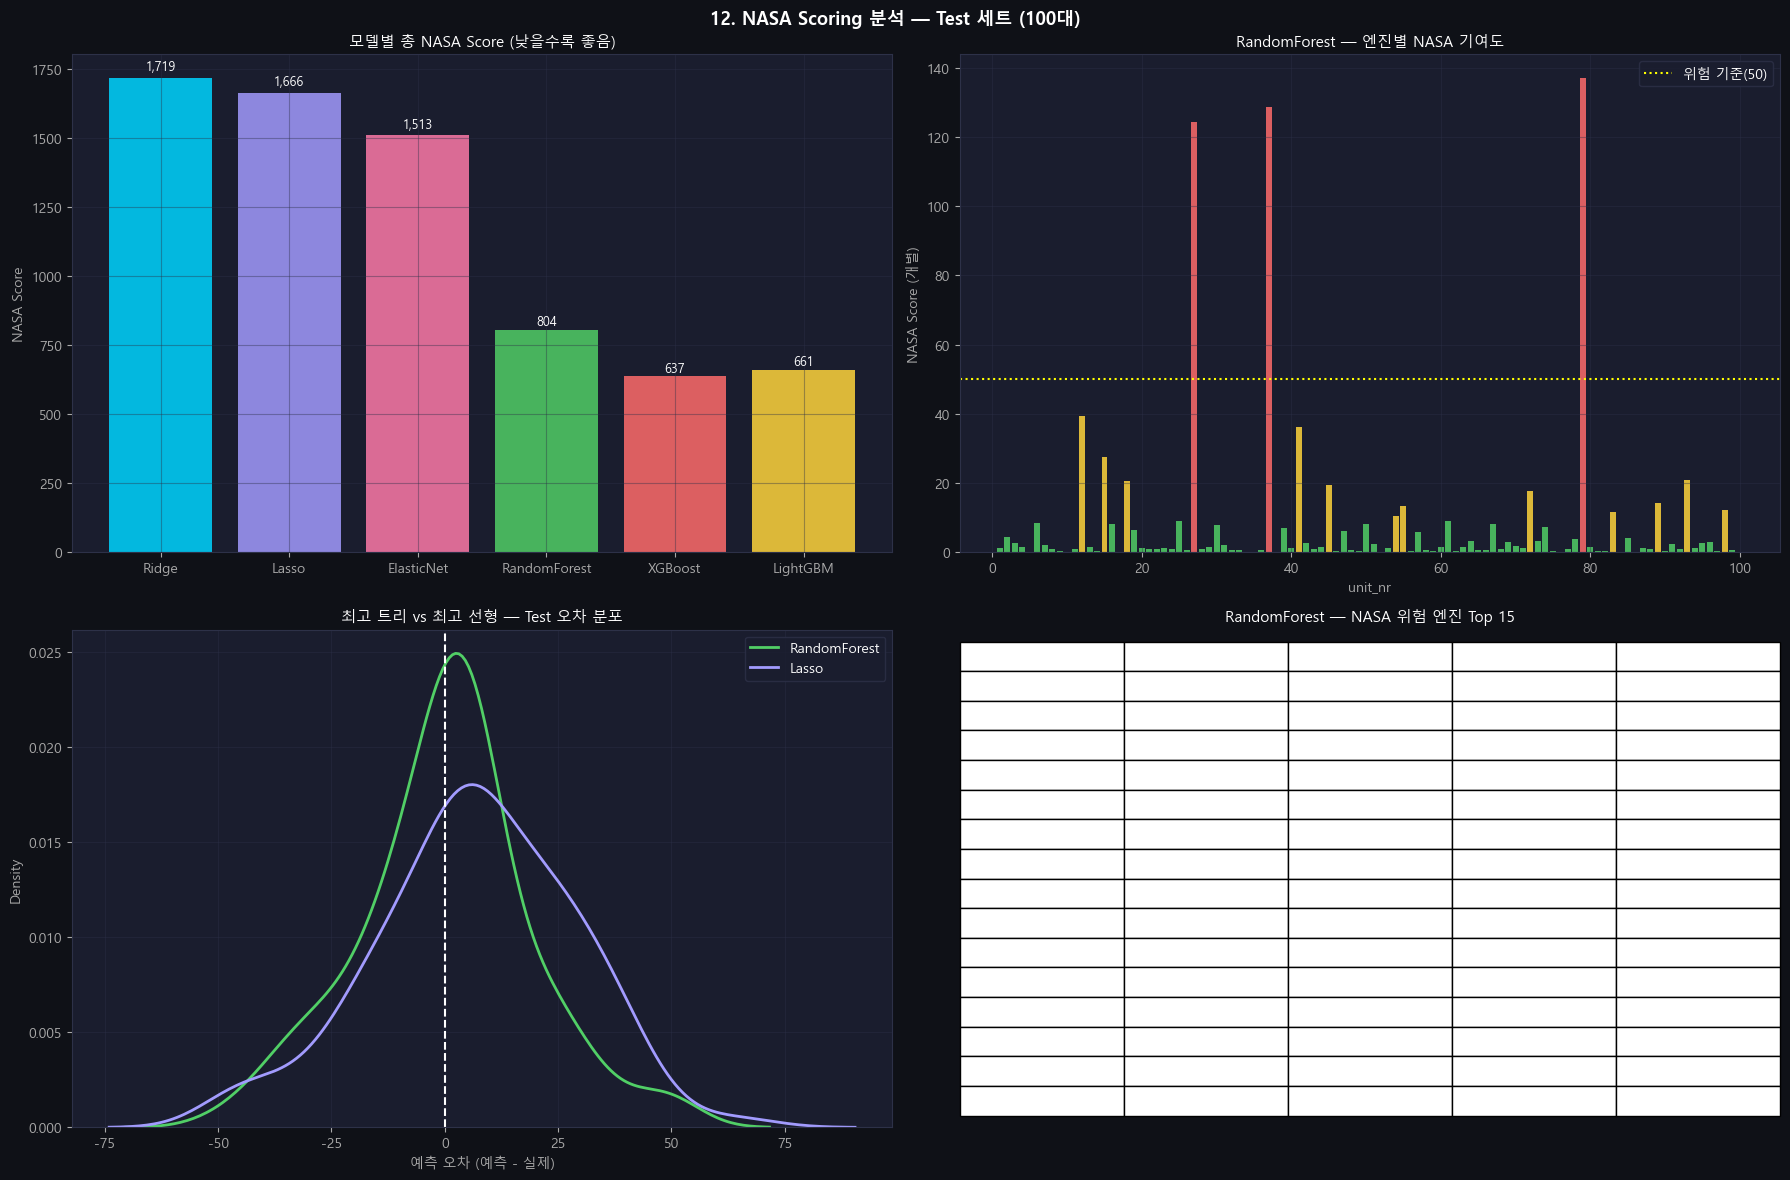

📄 NASA 위험 엔진 저장: results_ml\nasa_risk_engines.csv


In [16]:

print('=== 12. NASA Score 상세 분석 ===')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('12. NASA Scoring 분석 — Test 세트 (100대)', fontsize=13, fontweight='bold')

# 모델별 총 NASA Score
ax = axes[0, 0]
scores = {m: ALL_RESULTS[m]['test_metrics']['NASA_Score'] for m in ALL_RESULTS}
bars = ax.bar(scores.keys(), scores.values(), color=[MODEL_COLORS[m] for m in scores], alpha=0.85)
ax.set_title('모델별 총 NASA Score (낮을수록 좋음)')
ax.set_ylabel('NASA Score')
for bar, v in zip(bars, scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_facecolor(BG2)

# 최고 모델 엔진별 NASA 기여도
ax = axes[0, 1]
pred_best = test_pred_all[best_model_name]
d = pred_best - y_test.values
per_engine_ns = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
colors_ns = [C[1] if v > 50 else (C[3] if v > 10 else C[2]) for v in per_engine_ns]
ax.bar(test_eval['unit_nr'], per_engine_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', lw=1.5, ls=':', label='위험 기준(50)')
ax.set_title(f'{best_model_name} — 엔진별 NASA 기여도')
ax.set_xlabel('unit_nr')
ax.set_ylabel('NASA Score (개별)')
ax.legend()
ax.set_facecolor(BG2)

# 조기/늦은 예측 오차 분포
ax = axes[1, 0]
for mname in [best_tree_name, best_lin_name]:
    errs = test_pred_all[mname] - y_test.values
    sns.kdeplot(errs, ax=ax, fill=False, linewidth=2, label=mname, color=MODEL_COLORS[mname])
ax.axvline(0, color='white', lw=1.5, ls='--')
ax.set_title('최고 트리 vs 최고 선형 — Test 오차 분포')
ax.set_xlabel('예측 오차 (예측 - 실제)')
ax.legend()
ax.set_facecolor(BG2)

# 위험 엔진 표
ax = axes[1, 1]
risk_df = pd.DataFrame({
    'unit_nr': test_eval['unit_nr'],
    'actual_rul': y_test.values,
    'pred_rul': pred_best,
    'error': d,
    'nasa_contrib': per_engine_ns
}).sort_values('nasa_contrib', ascending=False).head(15)

ax.axis('off')
tbl = ax.table(
    cellText=np.round(risk_df.values, 2),
    colLabels=risk_df.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title(f'{best_model_name} — NASA 위험 엔진 Top 15')

plt.tight_layout()
plt.show()

risk_path = os.path.join(RESULT_DIR, 'nasa_risk_engines.csv')
risk_df.to_csv(risk_path, index=False, encoding='utf-8-sig')
print(f'📄 NASA 위험 엔진 저장: {risk_path}')


## 13. 모델 및 산출물 저장

In [17]:

print('=== 13. 모델 및 산출물 저장 ===')

# 모델 저장
for mname, model in BEST_MODELS.items():
    model_path = os.path.join(MODEL_DIR, f'FD001_{mname}.pkl')
    joblib.dump(model, model_path)
    size_kb = os.path.getsize(model_path) / 1024
    print(f'  저장: {model_path} ({size_kb:.1f} KB)')

# 피처 목록 저장
tree_feat_path = os.path.join(MODEL_DIR, 'FD001_features_tree.txt')
with open(tree_feat_path, 'w', encoding='utf-8') as f:
    for feat in FEATURES_TREE:
        f.write(feat + '\n')

lin_feat_path = os.path.join(MODEL_DIR, 'FD001_features_linear.txt')
with open(lin_feat_path, 'w', encoding='utf-8') as f:
    for feat in FEATURES_LINEAR:
        f.write(feat + '\n')

summary_json = {
    'shap_model_name': shap_model_name,
    'shap_top_features': shap_imp.head(10)['feature'].tolist() if 'shap_imp' in globals() else [],
    'best_model_name': best_model_name,
    'best_tree_name': best_tree_name,
    'best_linear_name': best_lin_name,
    'selection_rule': 'Val NASA(eval) -> Val RMSE',
    'random_state': RANDOM_STATE,
    'n_splits_cv': N_SPLITS_CV,
    'feature_count_tree': len(FEATURES_TREE),
    'feature_count_linear': len(FEATURES_LINEAR),
    'best_model_params': ALL_RESULTS[best_model_name]['params'],
    'best_model_val_eval_nasa': ALL_RESULTS[best_model_name]['val_eval_nasa'],
    'best_model_val_metrics': ALL_RESULTS[best_model_name]['val_metrics'],
    'best_model_test_metrics': ALL_RESULTS[best_model_name]['test_metrics'],
}
summary_json_path = os.path.join(RESULT_DIR, 'best_model_summary.json')
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)

# MLflow 부모 run에 아티팩트 업로드
active_run = mlflow.active_run()
if active_run is not None:
    for artifact_path in [
        os.path.join(RESULT_DIR, 'model_comparison.csv'),
        os.path.join(RESULT_DIR, 'test_engine_predictions.csv'),
        os.path.join(RESULT_DIR, 'validation_segment_mae.csv'),
        summary_json_path,
        corr_pairs_path,
        shap_imp_path if 'shap_imp_path' in globals() else '',
    ]:
        if os.path.exists(artifact_path):
            mlflow.log_artifact(artifact_path)

print(f'\n✅ 저장 완료')
print(f'  모델 폴더   : {os.path.abspath(MODEL_DIR)}')
print(f'  결과 폴더   : {os.path.abspath(RESULT_DIR)}')
print(f'  MLflow 폴더 : {os.path.abspath(MLFLOW_DIR)}')


# 부모 run 종료
if mlflow.active_run() is not None:
    mlflow.end_run()
    print('✅ MLflow 부모 run 종료')


=== 13. 모델 및 산출물 저장 ===
  저장: models_ml\FD001_Ridge.pkl (1.8 KB)
  저장: models_ml\FD001_Lasso.pkl (1.9 KB)
  저장: models_ml\FD001_ElasticNet.pkl (1.9 KB)
  저장: models_ml\FD001_RandomForest.pkl (25223.8 KB)
  저장: models_ml\FD001_XGBoost.pkl (426.7 KB)
  저장: models_ml\FD001_LightGBM.pkl (2151.1 KB)

✅ 저장 완료
  모델 폴더   : c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\models_ml
  결과 폴더   : c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\results_ml
  MLflow 폴더 : c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\mlruns
✅ MLflow 부모 run 종료


## 14. 최종 요약 리포트

In [18]:

print('=' * 90)
print(' NASA C-MAPSS FD001 — 머신러닝 최종 요약 (MLflow)')
print('=' * 90)

print('\n[데이터]')
print(f'  Sub-train : {subtrain.shape[0]:,}행 | 엔진 {subtrain["unit_nr"].nunique()}대')
print(f'  Validation: {valid.shape[0]:,}행 | 엔진 {valid["unit_nr"].nunique()}대')
print(f'  Test(eval): {test_eval.shape[0]:,}행 | 엔진 {test_eval["unit_nr"].nunique()}대 (마지막 사이클)')
print(f'  피처(선형): {len(FEATURES_LINEAR)}개 | 피처(트리): {len(FEATURES_TREE)}개')

print('\n[모델 선택 기준]')
print('  1) Val NASA Score — 엔진별 마지막 사이클 기준 (Test와 동일한 방식)')
print('  2) Val RMSE (동률 시 보조)')
print('  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음')
print('  ※ 정규화: 전처리 MinMaxScaler 단일 사용 (StandardScaler 이중 적용 제거)')

print('\n[최종 순위 — Validation/CV 기준]')
rank_view = result_df[['선정순위','모델','구분','Val NASA(eval)','Val RMSE','CV RMSE','Test NASA','Test RMSE']]
display(rank_view)

print(f'\n[전체 최고 모델] {best_model_name}')
bm = ALL_RESULTS[best_model_name]
print(f'  CV RMSE          : {bm["cv_rmse"]:.3f} ± {bm["cv_rmse_std"]:.3f}')
print(f'  Val NASA(eval)   : {bm["val_eval_nasa"]:.1f}')
print(f'  Validation(full) : RMSE={bm["val_metrics"]["RMSE"]:.3f}, MAE={bm["val_metrics"]["MAE"]:.3f}, R²={bm["val_metrics"]["R2"]:.4f}')
print(f'  Test         : RMSE={bm["test_metrics"]["RMSE"]:.3f}, MAE={bm["test_metrics"]["MAE"]:.3f}, '
      f'R²={bm["test_metrics"]["R2"]:.4f}, NASA={bm["test_metrics"]["NASA_Score"]:.1f}')
print(f'  Best Params  : {bm["params"]}')

print(f'\n[최고 트리 / 최고 선형]')
print(f'  Tree   : {best_tree_name}')
print(f'  Linear : {best_lin_name}')

print('\n[SHAP 해석]')
print(f'  해석 모델     : {shap_model_name}')
print(f'  Top SHAP 변수 : {", ".join(shap_imp.head(5)["feature"].tolist())}')

print('\n[MLflow 활용]')
print(f'  Tracking URI : {mlflow.get_tracking_uri()}')
print(f'  Experiment   : {EXPERIMENT_NAME}')
print('  기록 항목     : 파라미터 / CV·Val·Test 메트릭 / 모델 / CSV 아티팩트')

print('\n[다음 단계 추천]')
print('  1. SHAP 결과를 바탕으로 핵심 센서 후보 압축')
print('  2. FD002~FD004까지 동일 구조 확장')
print('  3. DL(LSTM, GRU, Transformer) 결과와 정량 비교')
print('  4. 최고 트리 + 최고 선형 앙상블 실험')
print('=' * 90)


 NASA C-MAPSS FD001 — 머신러닝 최종 요약 (MLflow)

[데이터]
  Sub-train : 16,561행 | 엔진 80대
  Validation: 4,070행 | 엔진 20대
  Test(eval): 100행 | 엔진 100대 (마지막 사이클)
  피처(선형): 48개 | 피처(트리): 140개

[모델 선택 기준]
  1) Val NASA Score — 엔진별 마지막 사이클 기준 (Test와 동일한 방식)
  2) Val RMSE (동률 시 보조)
  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음
  ※ 정규화: 전처리 MinMaxScaler 단일 사용 (StandardScaler 이중 적용 제거)

[최종 순위 — Validation/CV 기준]


,선정순위,모델,구분,Val NASA(eval),Val RMSE,CV RMSE,Test NASA,Test RMSE
0,1,RandomForest,트리,4.1,15.687,18.506,804.3,18.662
1,2,LightGBM,트리,6.5,15.767,18.259,661.0,19.532
2,3,XGBoost,트리,9.5,15.154,17.686,636.9,18.188
3,4,Lasso,선형,28.0,18.925,20.416,1665.9,22.663
4,5,Ridge,선형,31.2,18.929,20.408,1718.6,22.810
5,6,ElasticNet,선형,31.9,19.050,20.473,1512.6,22.333



[전체 최고 모델] RandomForest
  CV RMSE          : 18.506 ± 1.761
  Val NASA(eval)   : 4.1
  Validation(full) : RMSE=15.687, MAE=10.926, R²=0.8586
  Test         : RMSE=18.662, MAE=13.892, R²=0.7983, NASA=804.3
  Best Params  : {'n_estimators': 251, 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 0.43298331215843355}

[최고 트리 / 최고 선형]
  Tree   : RandomForest
  Linear : Lasso

[SHAP 해석]
  해석 모델     : RandomForest
  Top SHAP 변수 : s_4, s_4_roll3, s_11, s_4_ema5, s_9

[MLflow 활용]
  Tracking URI : file:///C:/Users/matth/OneDrive/%EB%B0%94%ED%83%95%20%ED%99%94%EB%A9%B4/%EB%B6%80%EC%BA%A0/%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8/%EC%B5%9C%EC%A2%85%20%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8/cmapss/mlruns
  Experiment   : CMAPSS_FD001_ML
  기록 항목     : 파라미터 / CV·Val·Test 메트릭 / 모델 / CSV 아티팩트

[다음 단계 추천]
  1. SHAP 결과를 바탕으로 핵심 센서 후보 압축
  2. FD002~FD004까지 동일 구조 확장
  3. DL(LSTM, GRU, Transformer) 결과와 정량 비교
  4. 최고 트리 + 최고 선형 앙상블 실험
